# CSI Channel Decomposition: Digital Twin-Based Static Prior

Analysis of the channel decomposition **H(t) = H_s + H_d(t) + noise**
starting from **raw H_combined** (no prior background subtraction).

## Core approach: DT-Based Static Prior

The Sionna EM-Digital Twin provides a zero-shot estimate of the static background:

```
H_s^DT  = mean { H_idle(t) }   ← Sionna RT output for empty room (no person)
H_d^DT(t) = H(t) − H_s^DT      ← dynamic residual (body-induced), zero-lag
```

**Key properties vs EMA baseline:**
- **Zero-shot**: no real-environment calibration needed (DT provides H_s offline)
- **Zero-lag**: no transient / adaptation period (contrast with EMA τ = 1/(1-α) steps)
- **Transferable**: H_s^DT computed in sim can decompose real data directly (zero-shot sim→real)

## Comparison baseline: EMA (data-driven, no DT)

```
H_bg[t] = α·H_bg[t−1] + (1−α)·H[t]    ← data-driven, no prior, lag ≈ τ steps
H_d^EMA[t] = H[t] − H_bg[t]
```

EMA does not use the DT → used only for EREC alpha-sweep analysis (Fig. 05).

## Diagnostic metrics

| Metric | Formula | Insight |
|--------|---------|---------|
| **DEF** | ‖H_d^DT‖² / ‖H‖² | Fraction of energy extracted as dynamic (per class) |
| **SER** | ‖H_s^DT‖² / ‖H‖² | Fraction captured by DT prior (activity-level comparison) |
| **DPE** | −Σ p_k log p_k (delay domain of H_d^DT) | Delay structure of dynamic component |
| **EREC** | E_d(α) vs α (EMA baseline) | Principled EMA α selection for comparison |

> **Dataset**: H_combined = H_s + H_d (raw, unprocessed) from `dataset_har_raw.npz`.

## 0. Setup

In [14]:
import os
import itertools
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.patches import Ellipse
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

matplotlib.rcParams.update({
    'font.family':        'DejaVu Sans',
    'font.size':           12,
    'axes.titlesize':      14,
    'axes.labelsize':      13,
    'xtick.labelsize':     11,
    'ytick.labelsize':     11,
    'legend.fontsize':     11,
    'legend.title_fontsize': 11,
    'figure.dpi':         150,
    'savefig.dpi':        300,
    'axes.grid':           True,
    'grid.alpha':          0.3,
    'axes.spines.top':     False,
    'axes.spines.right':   False,
    'axes.titlepad':       8,
    'axes.labelpad':       6,
})


In [15]:
CLASSES = ['FALL', 'IDLE', 'JUMP', 'RUN', 'STAND', 'WALK']
CLASS_COLORS = {
    'FALL':  '#e74c3c',
    'IDLE':  '#3498db',
    'JUMP':  '#1abc9c',
    'RUN':   '#e67e22',
    'STAND': '#2ecc71',
    'WALK':  '#f39c12',
}
NC = len(CLASSES)

OUT_DIR   = 'figs/dataset_v2/bayesian_plots'
ALPHA_OPT = 0.80    # EMA parameter (used for H_d throughout)
N_CIR_BINS = 127    # first 10% of 1272 subcarriers for CIR display

os.makedirs(OUT_DIR, exist_ok=True)

def save_fig(fig, stem):
    for ext in ('png', 'pdf'):
        fig.savefig(f'{OUT_DIR}/{stem}.{ext}', dpi=300, bbox_inches='tight')
    print(f'Saved: {stem}.png/.pdf')

print(f'Config: ALPHA_OPT={ALPHA_OPT}  CIR_BINS={N_CIR_BINS}  OUT={OUT_DIR}/')

Config: ALPHA_OPT=0.8  CIR_BINS=127  OUT=figs/dataset_v2/bayesian_plots/


## 1. Dataset Loading

In [ ]:
def load_dataset(npz_path, rx_filter=None):
    print(f'Loading {npz_path} ...', flush=True)
    d = np.load(npz_path)
    X, y, rx = d['X'].astype(np.float32), d['y'], d['rx_ids']
    if rx_filter is not None:
        mask = rx == rx_filter
        X, y = X[mask], y[mask]
        print(f'  rx={rx_filter} filter: {mask.sum()} samples')
    print(f'  X shape: {X.shape}  classes: {np.unique(y)}')
    return X, y

# Raw H_combined: H_s + H_d, no prior subtraction
# SIM: filter to rx0 to match REAL (single-receiver comparison)
X_sim,  y_sim  = load_dataset('dataset_v2/dataset_har_combined.npz',      rx_filter=8)
X_real, y_real = load_dataset('dataset_real_v2/dataset_har_combined.npz')

# Complex channel matrix H(f,t) = RE + j*IM  shape (N, T=40, S=1272)
H_sim  = (X_sim[..., 0]  + 1j * X_sim[..., 1]).astype(np.complex64)
H_real = (X_real[..., 0] + 1j * X_real[..., 1]).astype(np.complex64)
print(f'H_sim: {H_sim.shape}   H_real: {H_real.shape}')

Loading dataset_v2/dataset_har_combined.npz ...
  rx=0 filter: 300 samples
  X shape: (300, 40, 1272, 4)  classes: ['FALL' 'IDLE' 'JUMP' 'RUN' 'STAND' 'WALK']
Loading dataset_real_v2/dataset_har_combined.npz ...
  X shape: (300, 40, 1272, 4)  classes: ['FALL' 'IDLE' 'JUMP' 'RUN' 'STAND' 'WALK']
H_sim: (300, 40, 1272)   H_real: (300, 40, 1272)


## 2. DT-Based Static Prior Estimation (H_s^DT)

The Digital Twin (Sionna RT) provides the empty-room channel via the IDLE class recordings.
For IDLE, no person is present → H_idle(t) ≈ H_s + noise → mean gives H_s^DT.

Three decompositions are computed:
- **DT-sim**: H_d^DT(t) = H_sim(t) − H_s^DT_sim   (in-domain, uses sim prior)
- **DT-real**: H_d^DT(t) = H_real(t) − H_s^DT_real  (calibrated real, uses real IDLE)
- **Zero-shot**: H_d^ZS(t) = H_real(t) − H_s^DT_sim  (no real data: DT sim prior on real channel)

In [17]:
mask_idle_sim  = (y_sim  == 'IDLE')
mask_idle_real = (y_real == 'IDLE')

# H_s^DT: average over all IDLE samples and all T time steps → static background prior
# Shape: (N_SC,) complex  — this is the DT estimate of the empty-room channel
H_s_dt_sim  = H_sim[mask_idle_sim].mean(axis=(0, 1))    # (1272,)
H_s_dt_real = H_real[mask_idle_real].mean(axis=(0, 1))  # (1272,)

# DT decomposition (zero-lag, no adaptation, no calibration data needed for zero-shot)
H_d_dt_sim       = H_sim  - H_s_dt_sim[None, None, :]    # (N, T, N_SC)
H_d_dt_real      = H_real - H_s_dt_real[None, None, :]   # (N, T, N_SC)  [calibrated real]
H_d_dt_zeroshot  = H_real - H_s_dt_sim[None, None, :]    # (N, T, N_SC)  [zero-shot: sim prior on real]

print(f'H_s^DT sim :  shape={H_s_dt_sim.shape}   mean|·|={np.abs(H_s_dt_sim).mean():.4f}')
print(f'H_s^DT real:  shape={H_s_dt_real.shape}   mean|·|={np.abs(H_s_dt_real).mean():.4f}')
print(f'H_d^DT sim :  shape={H_d_dt_sim.shape}')
print(f'H_d^DT real:  shape={H_d_dt_real.shape}')
print(f'H_d^DT zero:  shape={H_d_dt_zeroshot.shape}')

# DT prior quality: cosine similarity with real IDLE channel
cos_sim = (np.abs(np.vdot(H_s_dt_sim, H_s_dt_real)) /
           (np.linalg.norm(H_s_dt_sim) * np.linalg.norm(H_s_dt_real) + 1e-12))
print(f'\nDT prior alignment (cosine sim→real): {cos_sim:.4f}')

H_s^DT sim :  shape=(1272,)   mean|·|=0.7482
H_s^DT real:  shape=(1272,)   mean|·|=0.7142
H_d^DT sim :  shape=(300, 40, 1272)
H_d^DT real:  shape=(300, 40, 1272)
H_d^DT zero:  shape=(300, 40, 1272)

DT prior alignment (cosine sim→real): 0.9166


Saved: 02_bayesian_decomp_demo.png/.pdf


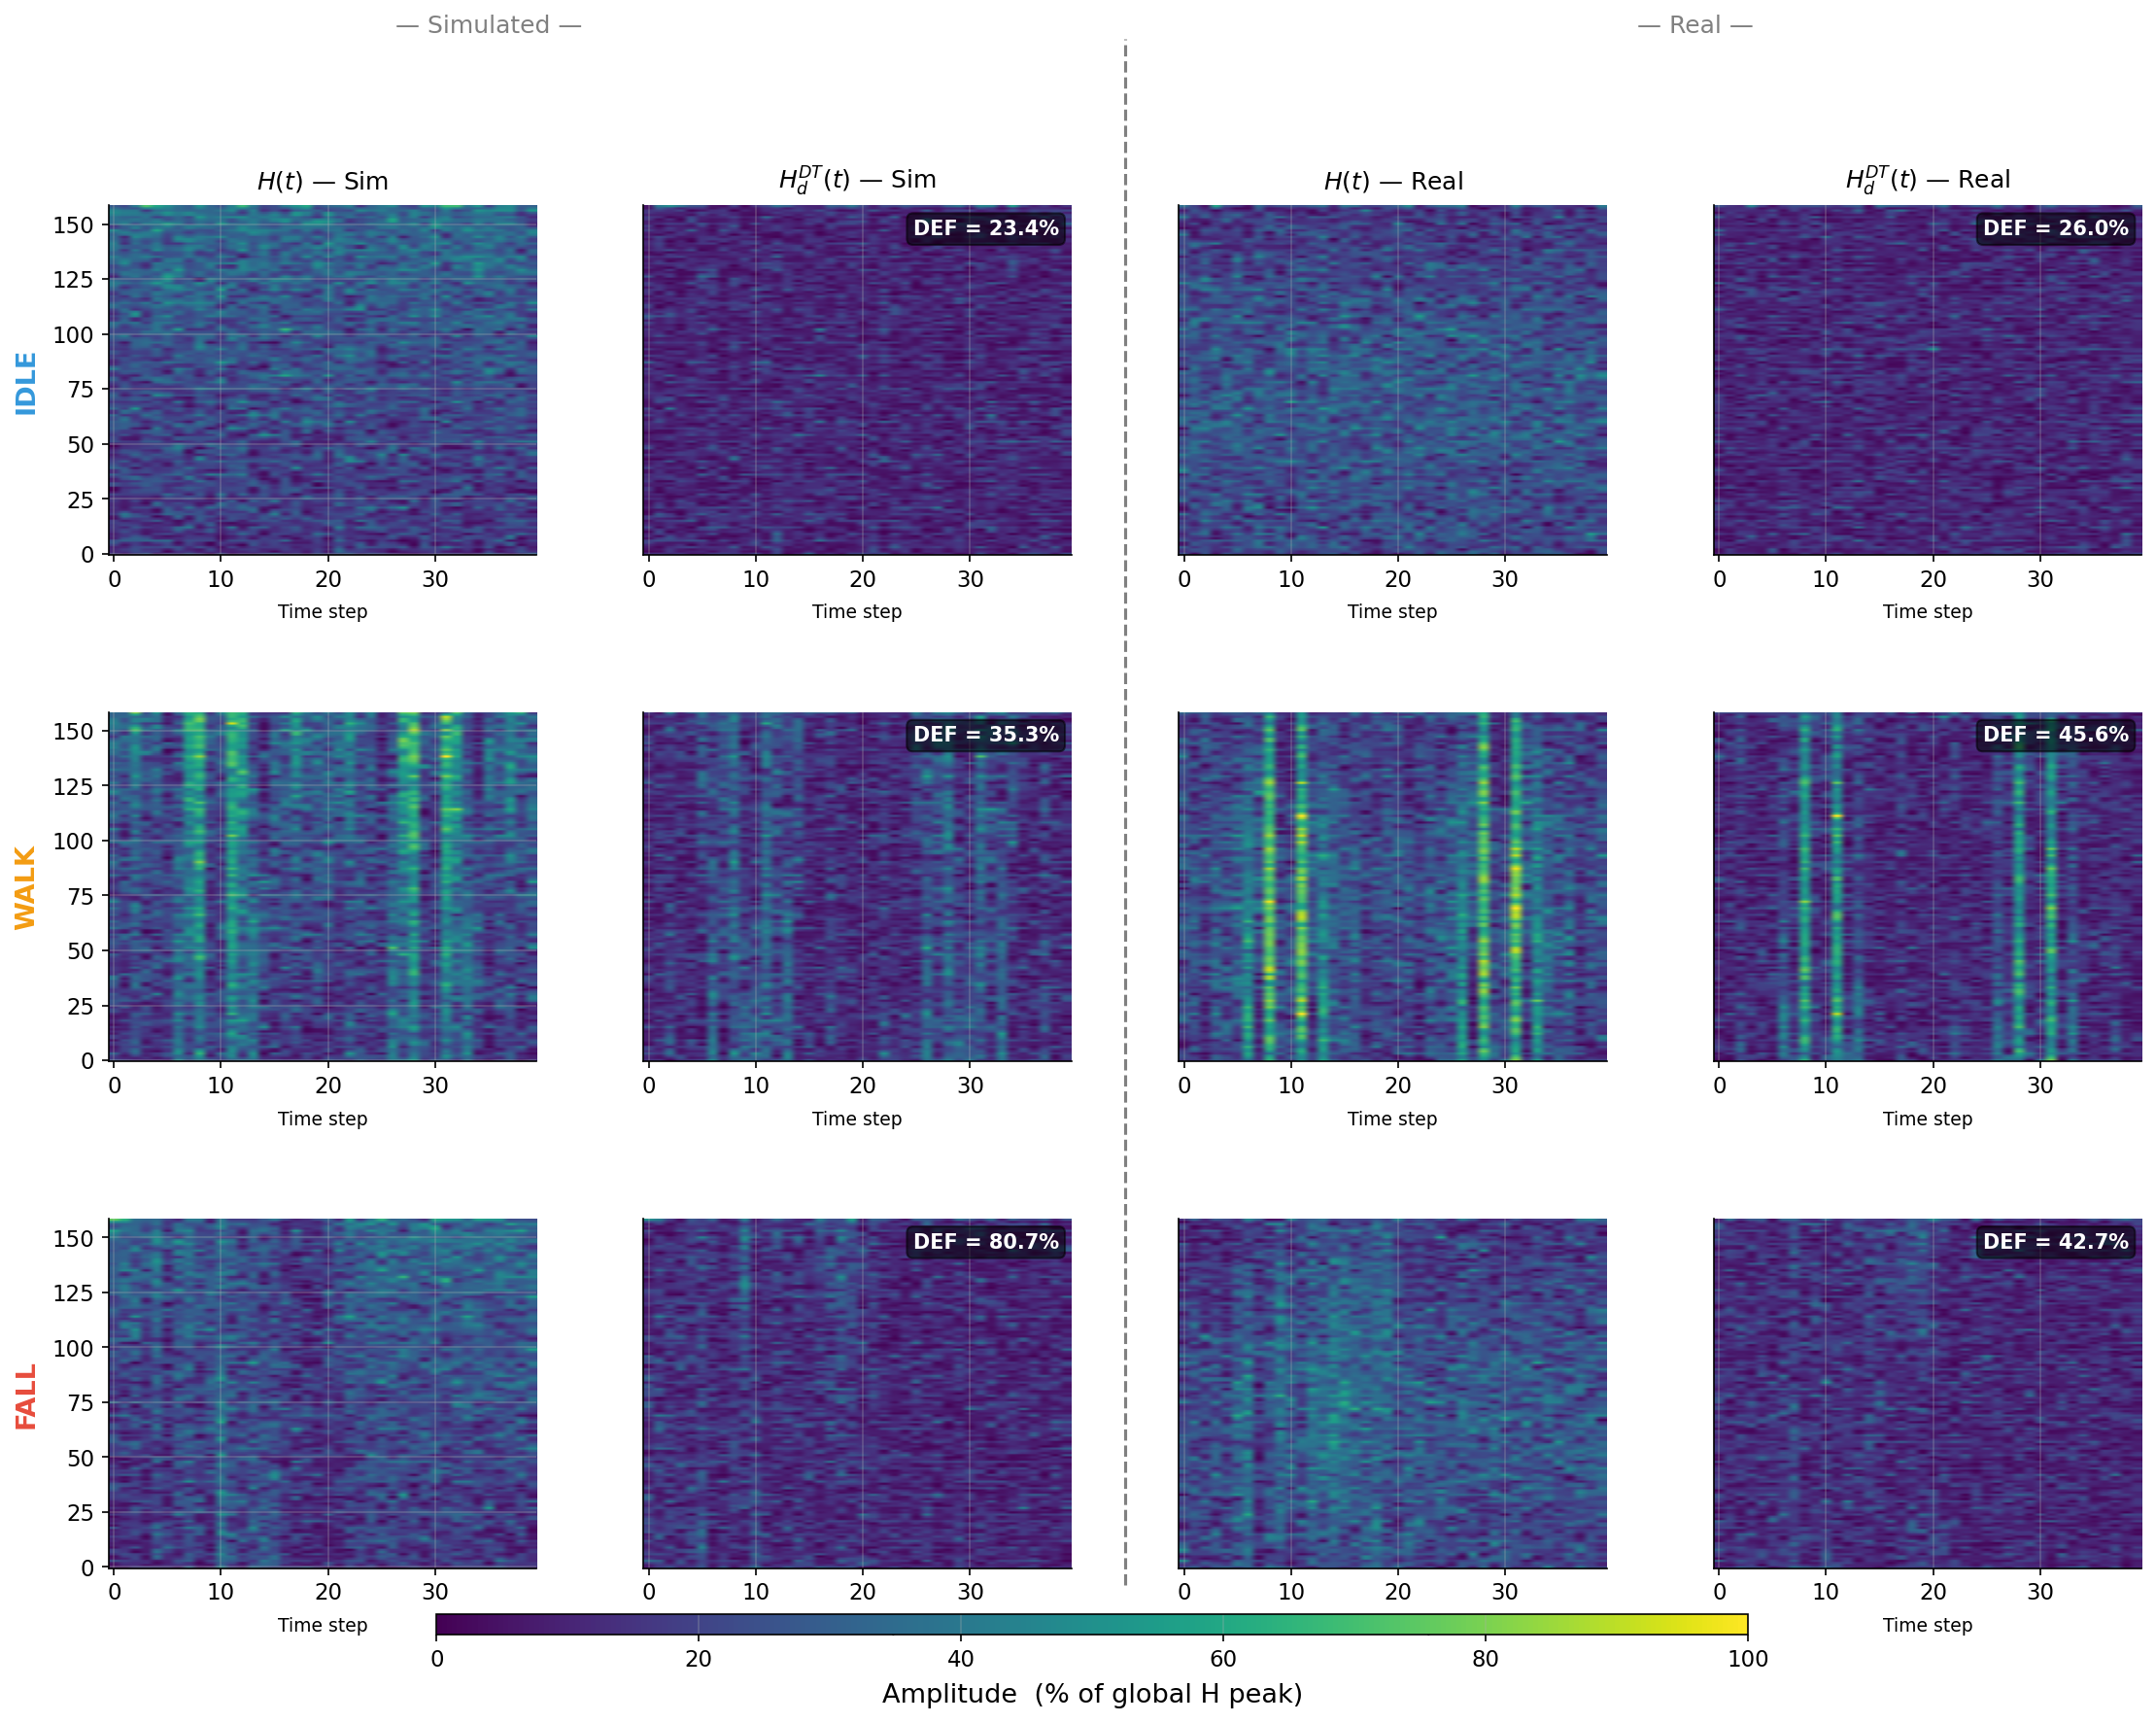

In [18]:
# ── Figure 02: DT Decomposition Demo ─────────────────────────────────────────
# Modular: change DEMO_CLASSES to show any subset (or all) of activity classes.
# Layout: len(DEMO_CLASSES) rows × 4 cols ([H(t) | H_d^DT(t)] × Sim / Real)
# H_d^DT panels annotated with class-mean DEF.

DEMO_CLASSES = ['IDLE', 'WALK', 'FALL']   # ← change here to show different classes
SC_STRIDE    = 8

# Global vref: 97th pct of |H| across ALL sim and real samples (not just DEMO_CLASSES)
vref = max(
    np.percentile(np.abs(H_sim),  97),
    np.percentile(np.abs(H_real), 97),
)

# Pre-compute per-class mean DEF for annotation
def mean_def(H_cx, H_d_cx, mask):
    E_d = (np.abs(H_d_cx[mask])**2).mean()
    E_h = (np.abs(H_cx[mask])**2).mean() + 1e-12
    return E_d / E_h

def_sim  = {cls: mean_def(H_sim,  H_d_dt_sim,  y_sim  == cls) for cls in CLASSES}
def_real = {cls: mean_def(H_real, H_d_dt_real, y_real == cls) for cls in CLASSES}

N_ROWS = len(DEMO_CLASSES)
fig, axes = plt.subplots(N_ROWS, 4, figsize=(18, 3.8 * N_ROWS))
if N_ROWS == 1:
    axes = axes[np.newaxis, :]   # keep 2-D indexing for single-row case
fig.subplots_adjust(hspace=0.45, wspace=0.25, bottom=0.06)

col_titles = [r'$H(t)$ — Sim', r'$H_d^{DT}(t)$ — Sim',
              r'$H(t)$ — Real', r'$H_d^{DT}(t)$ — Real']

hd_cols = {1: def_sim, 3: def_real}   # columns that carry H_d^DT

im_ref = None
for row, cls in enumerate(DEMO_CLASSES):
    idx_s = np.where(y_sim  == cls)[0][0]
    idx_r = np.where(y_real == cls)[0][0]

    panels = [
        H_sim[idx_s],        # H(t) sim
        H_d_dt_sim[idx_s],   # H_d^DT sim
        H_real[idx_r],       # H(t) real
        H_d_dt_real[idx_r],  # H_d^DT real
    ]

    for col, H_panel in enumerate(panels):
        ax  = axes[row, col]
        img = np.abs(H_panel[:, ::SC_STRIDE]).T / vref * 100.0
        im  = ax.imshow(img, aspect='auto', origin='lower',
                        cmap='viridis', vmin=0, vmax=100.0)
        im_ref = im

        if row == 0:
            ax.set_title(col_titles[col], fontsize=12)
        if col == 0:
            ax.set_ylabel(cls, color=CLASS_COLORS[cls], fontweight='bold', fontsize=13)
        else:
            ax.set_yticks([])
        ax.set_xlabel('Time step', fontsize=9)

        if col in hd_cols:
            def_val = hd_cols[col][cls]
            ax.text(0.97, 0.96, f'DEF = {def_val*100:.1f}%',
                    transform=ax.transAxes,
                    ha='right', va='top', fontsize=10, fontweight='bold',
                    color='white',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.55))

# Dashed divider between sim and real halves
pos1 = axes[0, 1].get_position()
pos2 = axes[0, 2].get_position()
xmid = (pos1.x1 + pos2.x0) / 2
fig.add_artist(plt.Line2D([xmid, xmid], [0.05, 0.98],
                           transform=fig.transFigure,
                           color='gray', linewidth=1.5, linestyle='--'))

fig.text(0.27, 0.995, '— Simulated —', ha='center', va='top', fontsize=12, color='gray')
fig.text(0.73, 0.995, '— Real —',       ha='center', va='top', fontsize=12, color='gray')

cax = fig.add_axes([0.25, 0.02, 0.50, 0.012])
cbar = fig.colorbar(im_ref, cax=cax, orientation='horizontal')
cbar.set_label('Amplitude  (% of global H peak)')

save_fig(fig, '02_bayesian_decomp_demo')
plt.show()
plt.close()

Saved: 02b_static_prior_spectrum.png/.pdf


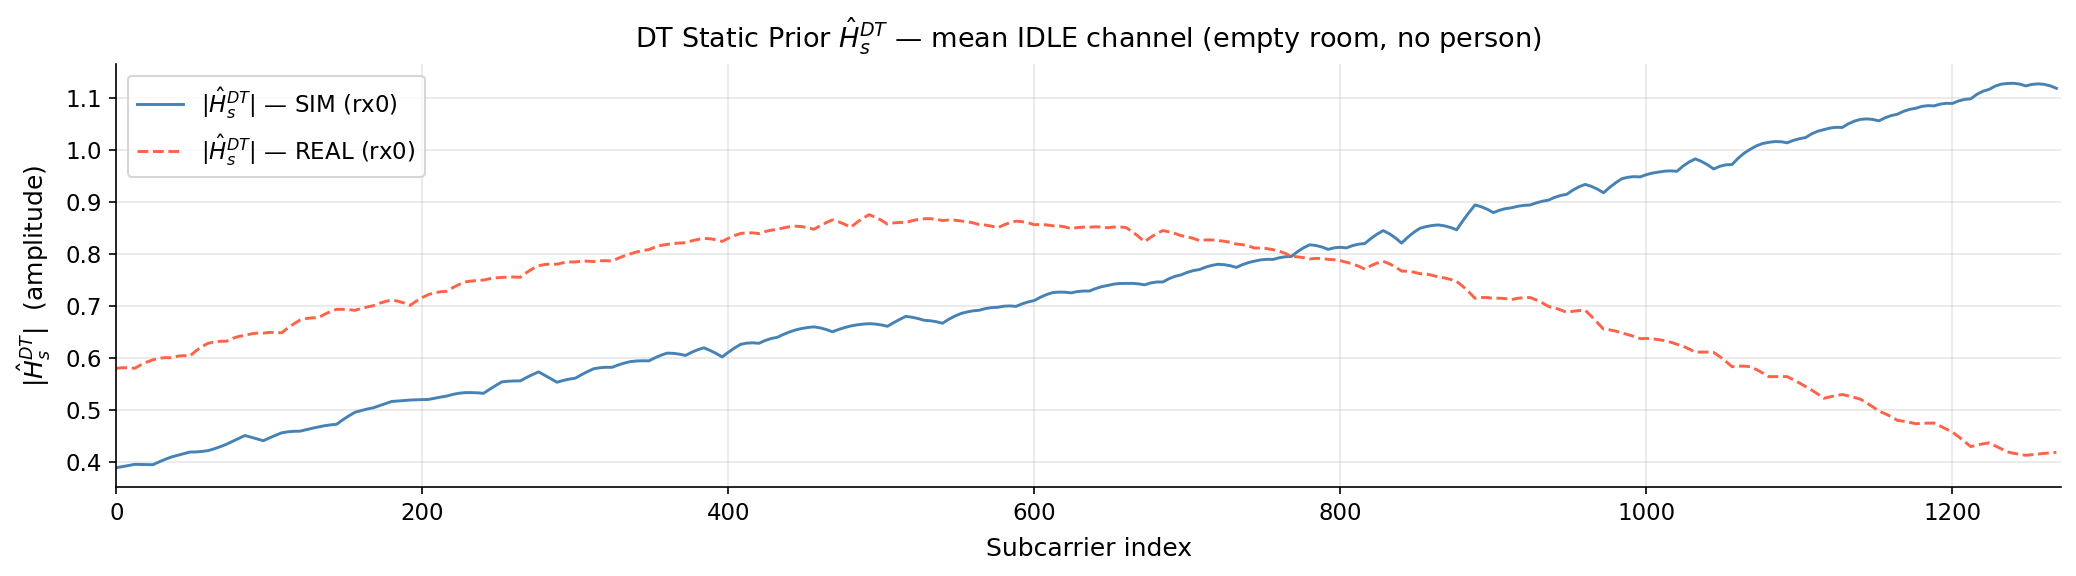

In [19]:
# ── Figure 02b: H_s^DT static prior ──────────────────────────────────────────
# Single subplot: |H_s^DT| vs subcarrier index for SIM and REAL
SC_STRIDE_S = 4
SC_ax = np.arange(0, H_s_dt_sim.shape[0], SC_STRIDE_S)

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(SC_ax, np.abs(H_s_dt_sim[::SC_STRIDE_S]),
        color='steelblue', lw=1.4, label=r'$|\hat{H}_s^{DT}|$ — SIM (rx0)')
ax.plot(SC_ax, np.abs(H_s_dt_real[::SC_STRIDE_S]),
        color='tomato', lw=1.4, linestyle='--', label=r'$|\hat{H}_s^{DT}|$ — REAL (rx0)')

ax.set_xlabel('Subcarrier index', fontsize=12)
ax.set_ylabel(r'$|\hat{H}_s^{DT}|$  (amplitude)', fontsize=12)
ax.set_title(r'DT Static Prior $\hat{H}_s^{DT}$ — mean IDLE channel (empty room, no person)',
             fontsize=13)
ax.set_xlim(0, H_s_dt_sim.shape[0] - 1)
ax.legend(fontsize=11)

plt.tight_layout()
save_fig(fig, '02b_static_prior_spectrum')
plt.show()
plt.close()

## 2. Channel Impulse Response (CIR) Analysis

Computing CIR on raw H_combined...
CIR shape: (300, 40, 1272)
Saved: 01_cir_profile_per_class.png/.pdf


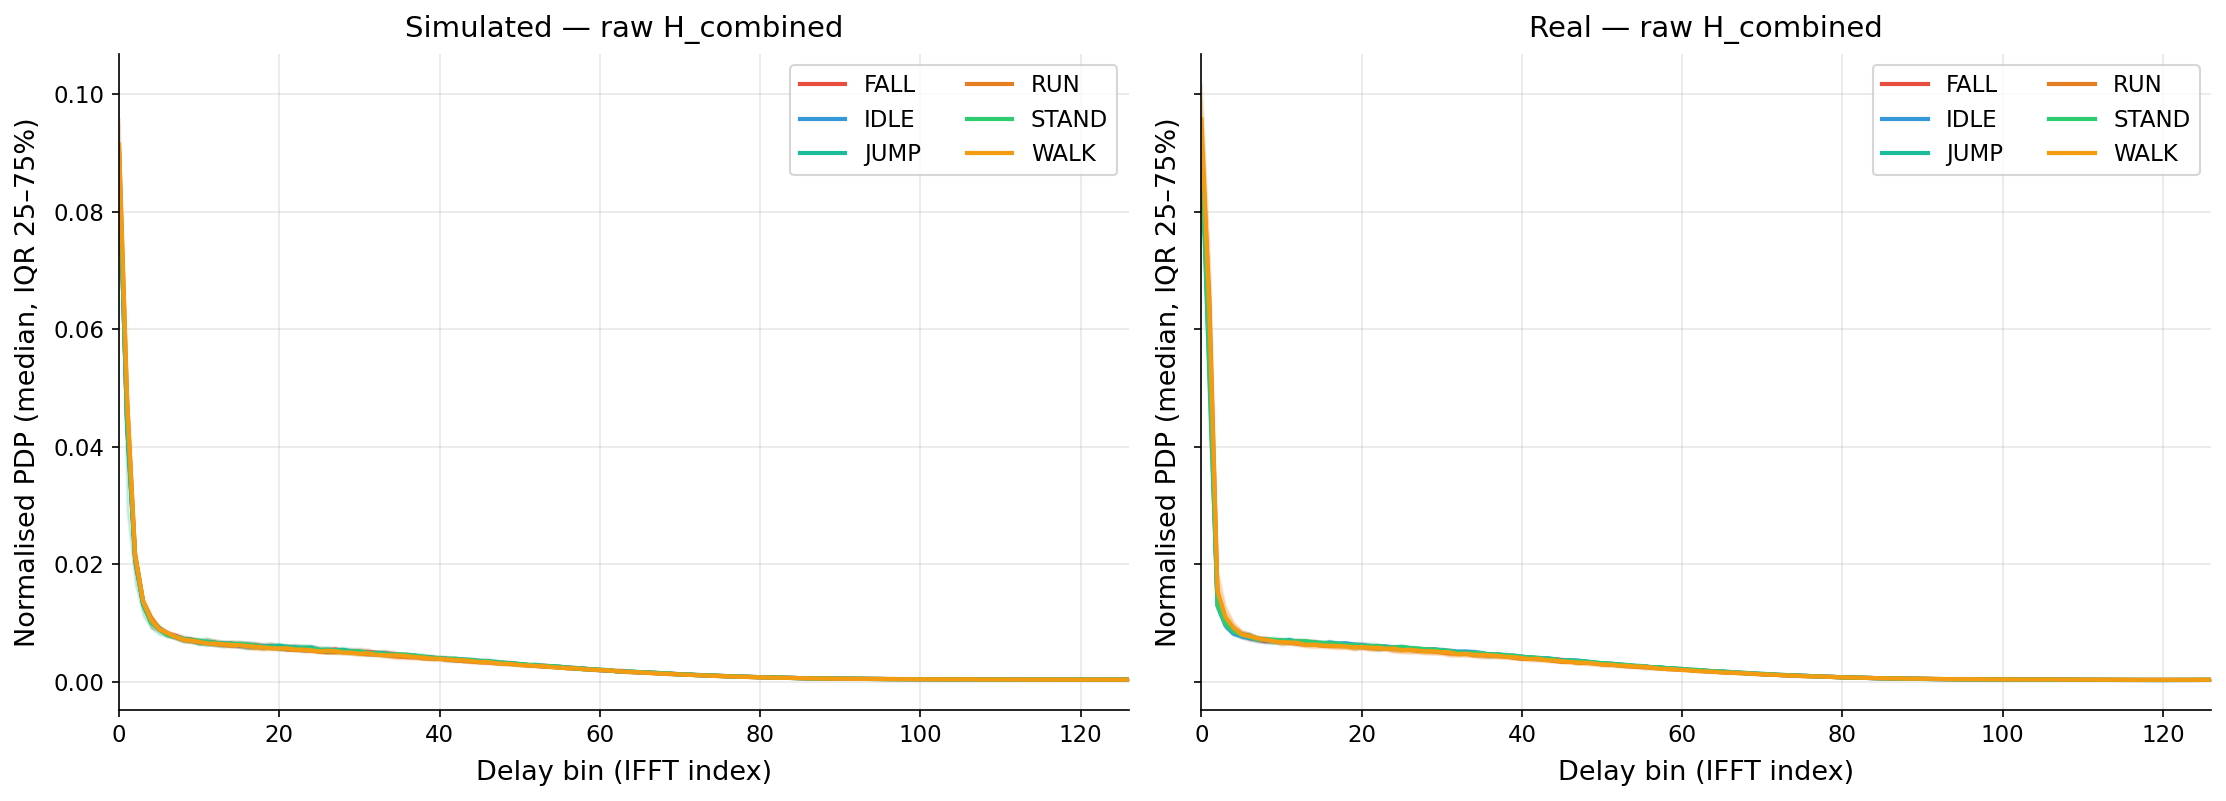

In [20]:
def compute_cir_raw(H_cx):
    """IFFT along subcarrier axis → CIR shape (N, T, S)."""
    return np.fft.ifft(H_cx, axis=2).astype(np.complex64)

print('Computing CIR on raw H_combined...', flush=True)
cir_sim  = compute_cir_raw(H_sim)
cir_real = compute_cir_raw(H_real)

cir_amp_sim  = np.abs(cir_sim).mean(axis=1)    # (N, S) time-averaged amplitude
cir_amp_real = np.abs(cir_real).mean(axis=1)
print('CIR shape:', cir_sim.shape)

def normalize_pdp(cir_amp):
    return cir_amp / (cir_amp.sum(axis=1, keepdims=True) + 1e-12)

pdp_sim  = normalize_pdp(cir_amp_sim)
pdp_real = normalize_pdp(cir_amp_real)

# Note: CIR of raw H is dominated by H_s — all classes show similar structure.
# This motivates the EMA decomposition to isolate H_d.
bins = np.arange(N_CIR_BINS)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)

for ax, (pdp, y, domain) in zip(axes, [
    (pdp_sim,  y_sim,  'Simulated — raw H_combined'),
    (pdp_real, y_real, 'Real — raw H_combined'),
]):
    for cls in CLASSES:
        mask = y == cls
        if not mask.any():
            continue
        chunk = pdp[mask, :N_CIR_BINS]
        med = np.median(chunk, axis=0)
        p25 = np.percentile(chunk, 25, axis=0)
        p75 = np.percentile(chunk, 75, axis=0)
        ax.plot(bins, med, color=CLASS_COLORS[cls], label=cls, linewidth=2.0)
        ax.fill_between(bins, p25, p75, color=CLASS_COLORS[cls], alpha=0.18)
    ax.set_xlabel('Delay bin (IFFT index)')
    ax.set_ylabel('Normalised PDP (median, IQR 25–75%)')
    ax.set_title(domain)
    ax.set_xlim(0, N_CIR_BINS - 1)
    ax.legend(ncol=2, loc='upper right')

plt.tight_layout()
save_fig(fig, '01_cir_profile_per_class')
plt.show()
plt.close()

## 3. EMA Baseline (data-driven, no DT)

The EMA filter tracks the background online without any prior knowledge.
Used here as a **comparison baseline** for the EREC alpha-sweep analysis (Fig. 05).

Note: EMA suffers from a transient lag of τ = 1/(1−α) steps and does not leverage
the Digital Twin — it is outperformed by the DT prior approach in zero-shot scenarios.

In [21]:
def ema_background(H_cx, alpha):
    """Causal EMA baseline: H_bg[t] = alpha*H_bg[t-1] + (1-alpha)*H[t].
    Data-driven — does not use any DT prior. Lag ≈ tau = 1/(1-alpha) steps.
    """
    N, T, S = H_cx.shape
    H_bg = np.empty_like(H_cx)
    H_bg[:, 0, :] = H_cx[:, 0, :]
    for t in range(1, T):
        H_bg[:, t, :] = alpha * H_bg[:, t-1, :] + (1.0 - alpha) * H_cx[:, t, :]
    return H_bg

# Compute EMA decomposition for EREC alpha-sweep only (Fig. 05)
print(f'EMA baseline (alpha={ALPHA_OPT}) — used only for EREC comparison figure...', flush=True)
H_bg_ema_sim  = ema_background(H_sim,  ALPHA_OPT)
H_bg_ema_real = ema_background(H_real, ALPHA_OPT)
H_d_ema_sim   = H_sim  - H_bg_ema_sim
H_d_ema_real  = H_real - H_bg_ema_real
print(f'EMA done. H_d_ema shape: {H_d_ema_sim.shape}')

EMA baseline (alpha=0.8) — used only for EREC comparison figure...
EMA done. H_d_ema shape: (300, 40, 1272)


## 4. Energy Decomposition: SER and DEF (DT prior)

**SER** (Static Energy Ratio) = ‖H_s^DT‖² / ‖H‖²: fraction of total energy captured by the DT static prior.
For IDLE, H ≈ H_s^DT → SER ≈ 1. For dynamic activities, H includes H_d → SER < 1.

**DEF** (Dynamic Energy Fraction) = ‖H_d^DT‖² / ‖H‖²: fraction extracted as dynamic residual.

Side-by-side comparison:
- **Left (SER)**: DT prior captures how much of the received energy — drops for dynamic activities
- **Right (DEF)**: activity-discriminating structure — FALL > RUN > WALK > STAND > IDLE

SER (DT prior) sim  per class: {'FALL': '0.5823', 'IDLE': '0.7656', 'JUMP': '0.6598', 'RUN': '0.6371', 'STAND': '0.6531', 'WALK': '0.6459'}
SER (DT prior) real per class: {'FALL': '0.6636', 'IDLE': '0.7398', 'JUMP': '0.7390', 'RUN': '0.5511', 'STAND': '0.7349', 'WALK': '0.5364'}
DEF (H_d^DT)   sim  per class: {'FALL': '0.4485', 'IDLE': '0.2345', 'JUMP': '0.4115', 'RUN': '0.3937', 'STAND': '0.4038', 'WALK': '0.3400'}
DEF (H_d^DT)   real per class: {'FALL': '0.3502', 'IDLE': '0.2604', 'JUMP': '0.4215', 'RUN': '0.4811', 'STAND': '0.3761', 'WALK': '0.4127'}
Saved: 03_static_energy_ratio.png/.pdf


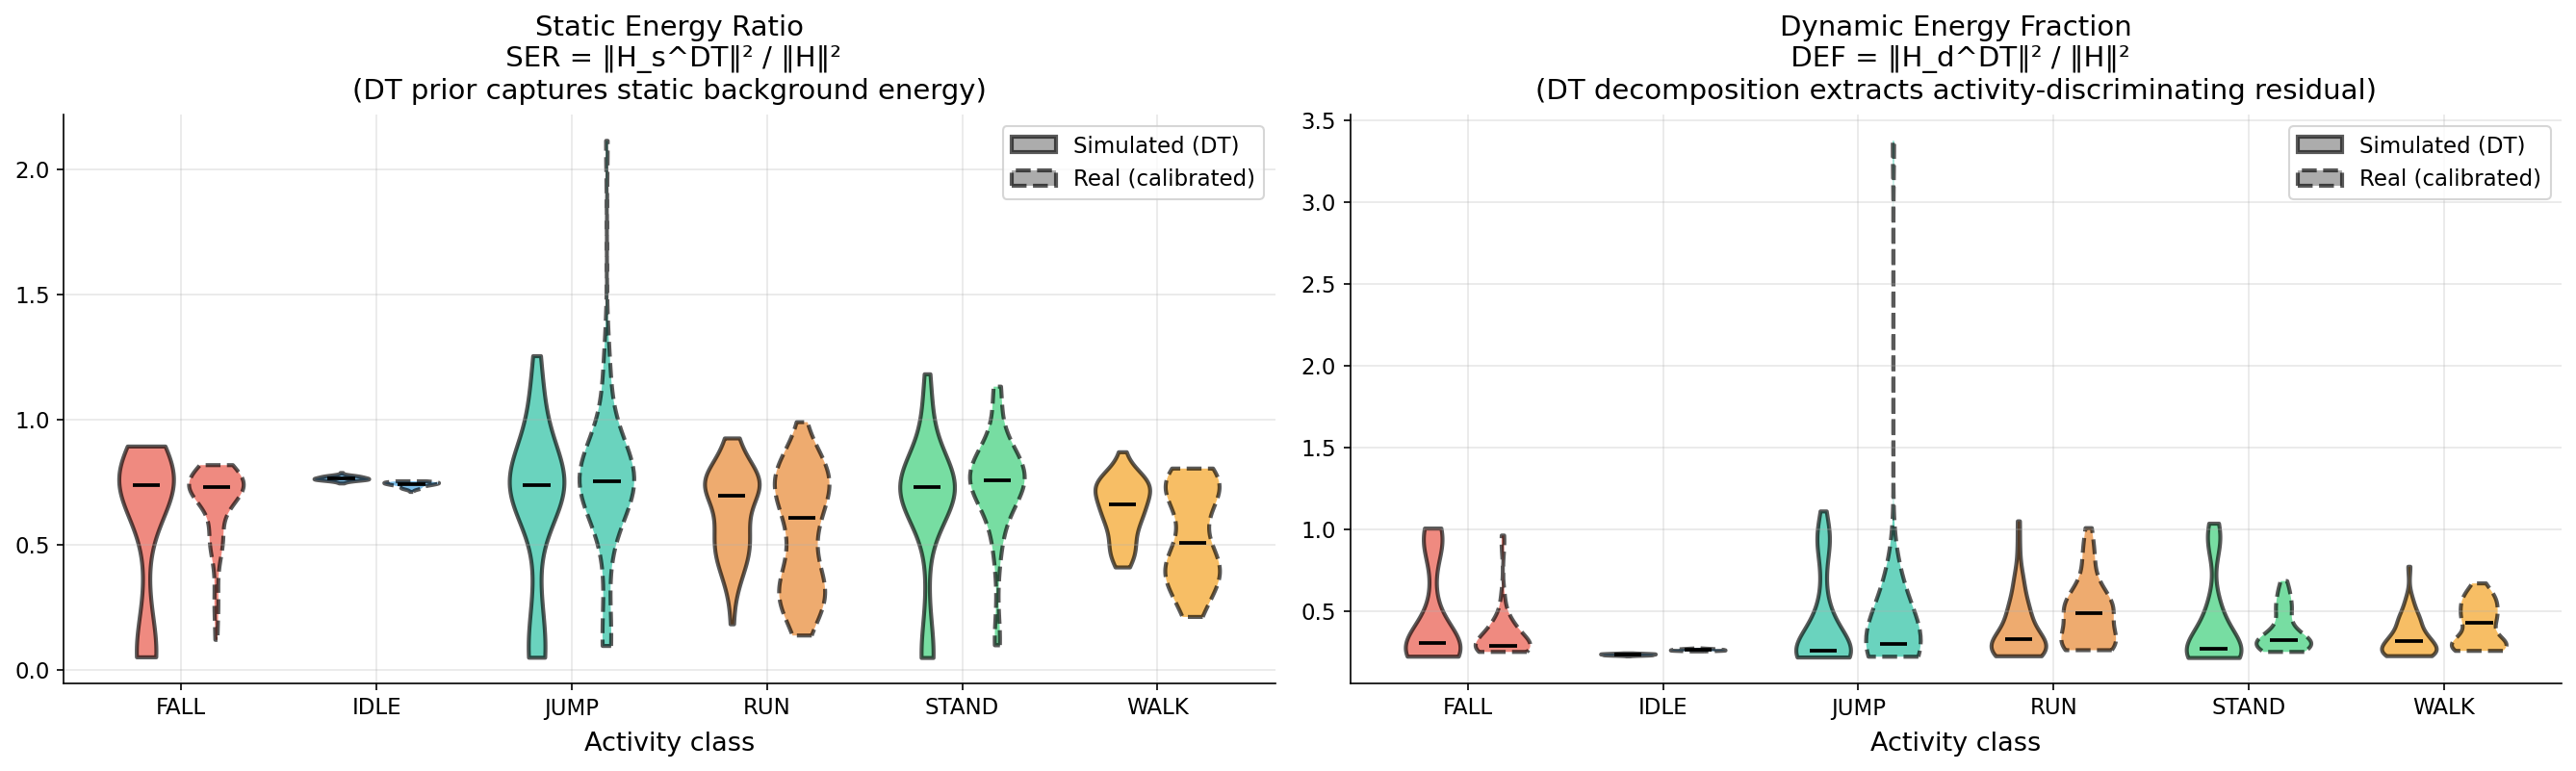

In [22]:
def dynamic_energy_fraction(H_cx, H_d_cx):
    """DEF = ||H_d^DT||_F^2 / ||H||_F^2  (fraction extracted as dynamic residual)."""
    E_d = (np.abs(H_d_cx)**2).mean(axis=(1, 2))
    E_h = (np.abs(H_cx)**2).mean(axis=(1, 2)) + 1e-12
    return (E_d / E_h).astype(np.float32)

# SER using DT prior: H_s^DT is fixed → scalar energy for all samples
# SER(i) = ||H_s^DT||^2_mean / ||H(i)||^2_mean
E_dt_s = float((np.abs(H_s_dt_sim)**2).mean())     # scalar (DT prior energy)
E_dt_r = float((np.abs(H_s_dt_real)**2).mean())

E_h_sim  = (np.abs(H_sim)**2).mean(axis=(1, 2)).astype(np.float32)   # (N,)
E_h_real = (np.abs(H_real)**2).mean(axis=(1, 2)).astype(np.float32)

SER_sim  = (E_dt_s / (E_h_sim  + 1e-12)).astype(np.float32)
SER_real = (E_dt_r / (E_h_real + 1e-12)).astype(np.float32)

# DEF using DT decomposition (H_d^DT)
DEF_sim  = dynamic_energy_fraction(H_sim,  H_d_dt_sim)
DEF_real = dynamic_energy_fraction(H_real, H_d_dt_real)

print('SER (DT prior) sim  per class:', {c: f'{SER_sim[y_sim==c].mean():.4f}'   for c in CLASSES if (y_sim==c).any()})
print('SER (DT prior) real per class:', {c: f'{SER_real[y_real==c].mean():.4f}' for c in CLASSES if (y_real==c).any()})
print('DEF (H_d^DT)   sim  per class:', {c: f'{DEF_sim[y_sim==c].mean():.4f}'   for c in CLASSES if (y_sim==c).any()})
print('DEF (H_d^DT)   real per class:', {c: f'{DEF_real[y_real==c].mean():.4f}' for c in CLASSES if (y_real==c).any()})

# ── Figure 03: SER (left) vs DEF (right) ─────────────────────────────────────
offset = 0.18
fig, axes = plt.subplots(1, 2, figsize=(18, 5.5))

panels = [
    (SER_sim, SER_real,
     'Static Energy Ratio\n SER = ‖H_s^DT‖² / ‖H‖²\n(DT prior captures static background energy)'),
    (DEF_sim, DEF_real,
     'Dynamic Energy Fraction\n DEF = ‖H_d^DT‖² / ‖H‖²\n(DT decomposition extracts activity-discriminating residual)'),
]

for ax, (DATA_sim, DATA_real, title) in zip(axes, panels):
    for i, cls in enumerate(CLASSES):
        for DATA, y, off, ls in [
            (DATA_sim,  y_sim,  -offset, '-'),
            (DATA_real, y_real, +offset, '--'),
        ]:
            mask = y == cls
            if not mask.any():
                continue
            parts = ax.violinplot([DATA[mask]], positions=[i + off], widths=0.28,
                                  showmedians=True, showextrema=False)
            for pc in parts['bodies']:
                pc.set_facecolor(CLASS_COLORS[cls])
                pc.set_alpha(0.65)
                pc.set_edgecolor('black')
                pc.set_linewidth(2.0)
                pc.set_linestyle(ls)
            parts['cmedians'].set_color('black')
            parts['cmedians'].set_linewidth(1.8)

    ax.set_xticks(range(NC))
    ax.set_xticklabels(CLASSES)
    ax.set_xlabel('Activity class')
    ax.set_title(title)

    h_sim  = mpatches.Patch(facecolor='gray', alpha=0.65, edgecolor='black',
                             linewidth=2.0, linestyle='-',  label='Simulated (DT)')
    h_real = mpatches.Patch(facecolor='gray', alpha=0.65, edgecolor='black',
                             linewidth=2.0, linestyle='--', label='Real (calibrated)')
    ax.legend(handles=[h_sim, h_real], loc='upper right')

plt.tight_layout()
save_fig(fig, '03_static_energy_ratio')
plt.show()
plt.close()

## 5. Delay Profile Entropy (DPE) on H_d^DT

DPE is computed on the **dynamic residual H_d^DT** obtained via DT prior subtraction.

DPE measures the spread of the mean power delay profile of H_d^DT across delay bins:
- **Low DPE**: dynamic energy concentrated at specific delays → body creates focused reflection paths
- **High DPE**: dynamic energy spread across many delay bins → noise-like, weak/absent dynamic component (IDLE)

DPE(H_d^DT) sim  per class: {'FALL': '4.50', 'IDLE': '4.77', 'JUMP': '4.36', 'RUN': '3.97', 'STAND': '4.42', 'WALK': '4.15'}
DPE(H_d^DT) real per class: {'FALL': '4.43', 'IDLE': '4.77', 'JUMP': '4.15', 'RUN': '3.74', 'STAND': '4.18', 'WALK': '3.91'}
Saved: 04_delay_profile_entropy.png/.pdf


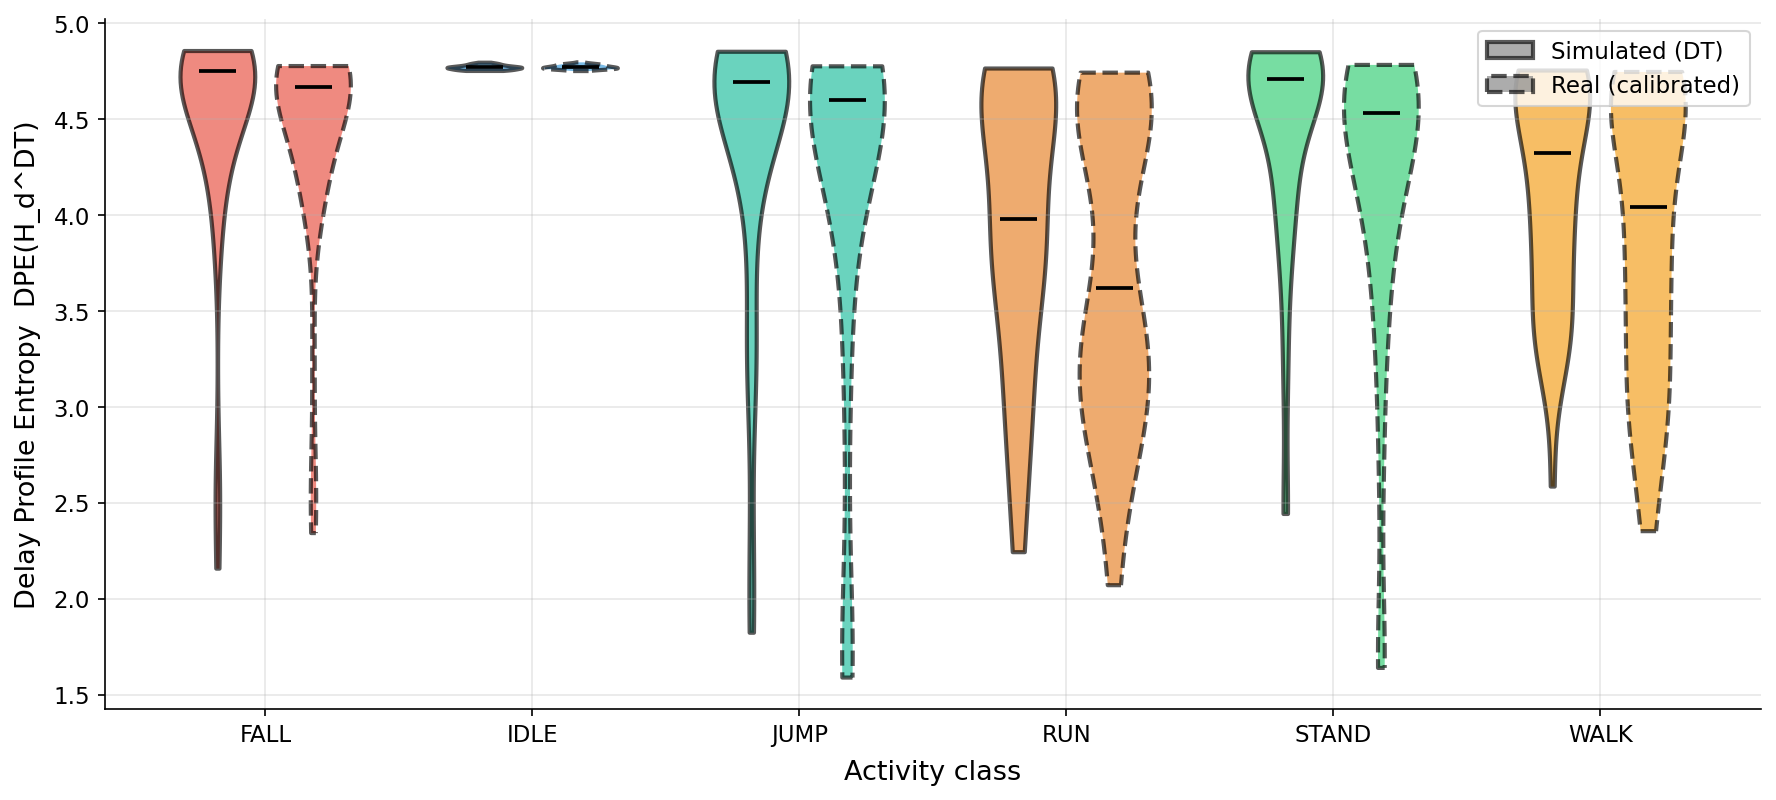

In [23]:
def compute_cir(H_cx):
    """IFFT along subcarrier axis → CIR(delay bins)."""
    return np.fft.ifft(H_cx, axis=2).astype(np.complex64)

def delay_profile_entropy(H_cx):
    """DPE on H_cx: entropy of mean power delay profile (over time).
    p_k = mean_t(|CIR[t,k]|)^2 / sum_k(...) per sample.
    """
    cir      = compute_cir(H_cx)            # (N, T, S)
    amp_mean = np.abs(cir).mean(axis=1)     # (N, S) — mean amplitude CIR
    pdp      = amp_mean ** 2                # (N, S) — power delay profile
    pdp_norm = pdp / (pdp.sum(axis=1, keepdims=True) + 1e-12)
    return (-(pdp_norm * np.log(pdp_norm + 1e-12)).sum(axis=1)).astype(np.float32)

# DPE on H_d^DT (dynamic component via DT prior subtraction)
DPE_sim  = delay_profile_entropy(H_d_dt_sim)
DPE_real = delay_profile_entropy(H_d_dt_real)

print('DPE(H_d^DT) sim  per class:', {c: f'{DPE_sim[y_sim==c].mean():.2f}'  for c in CLASSES if (y_sim==c).any()})
print('DPE(H_d^DT) real per class:', {c: f'{DPE_real[y_real==c].mean():.2f}' for c in CLASSES if (y_real==c).any()})

# ── Figure 04: DPE violin on H_d^DT ──────────────────────────────────────────
offset = 0.18
fig, ax = plt.subplots(figsize=(12, 5.5))

for i, cls in enumerate(CLASSES):
    for DPE, y, off, ls in [
        (DPE_sim,  y_sim,  -offset, '-'),
        (DPE_real, y_real, +offset, '--'),
    ]:
        mask = y == cls
        if not mask.any():
            continue
        parts = ax.violinplot([DPE[mask]], positions=[i + off], widths=0.28,
                              showmedians=True, showextrema=False)
        for pc in parts['bodies']:
            pc.set_facecolor(CLASS_COLORS[cls])
            pc.set_alpha(0.65)
            pc.set_edgecolor('black')
            pc.set_linewidth(2.0)
            pc.set_linestyle(ls)
        parts['cmedians'].set_color('black')
        parts['cmedians'].set_linewidth(1.8)

ax.set_xticks(range(NC))
ax.set_xticklabels(CLASSES)
ax.set_ylabel('Delay Profile Entropy  DPE(H_d^DT)')
ax.set_xlabel('Activity class')

h_sim  = mpatches.Patch(facecolor='gray', alpha=0.65, edgecolor='black',
                         linewidth=2.0, linestyle='-',  label='Simulated (DT)')
h_real = mpatches.Patch(facecolor='gray', alpha=0.65, edgecolor='black',
                         linewidth=2.0, linestyle='--', label='Real (calibrated)')
ax.legend(handles=[h_sim, h_real], loc='upper right')

plt.tight_layout()
save_fig(fig, '04_delay_profile_entropy')
plt.show()
plt.close()

## 7. Dynamic Discriminability Index (DDI)

Saved: 06_dynamic_discriminability_ddi.png/.pdf


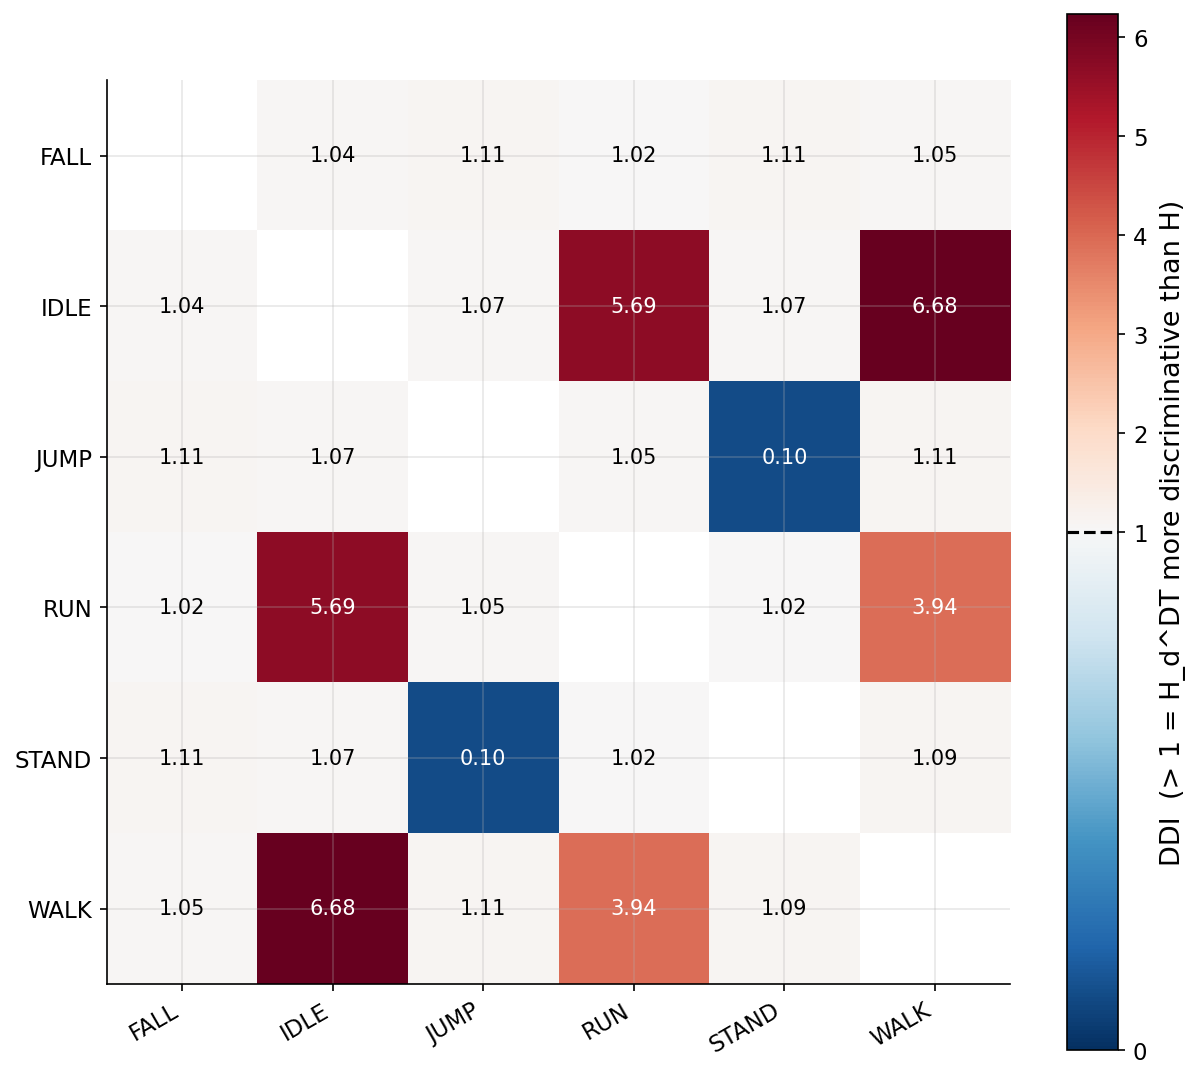


Top 5 class pairs with highest DDI (H_d^DT):
  IDLE vs WALK: DDI=6.678
  IDLE vs RUN: DDI=5.692
  RUN vs WALK: DDI=3.938
  FALL vs JUMP: DDI=1.111
  JUMP vs WALK: DDI=1.110


In [24]:
def amp_features(H_cx):
    """4 amplitude statistics per sample."""
    AMP = np.abs(H_cx).astype(np.float32)
    return np.column_stack([
        AMP.mean(axis=(1, 2)),
        AMP.var(axis=(1, 2)),
        AMP.var(axis=2).mean(axis=1),
        AMP.var(axis=1).mean(axis=1),
    ])

FEAT_NAMES_4 = ['mean_amp', 'var_amp', 'spectral_var', 'temporal_var']

F_H_sim  = amp_features(H_sim)
F_Hd_sim = amp_features(H_d_dt_sim)   # use DT decomposition

pairs = [(c1, c2) for i, c1 in enumerate(CLASSES) for c2 in CLASSES[i+1:]]

def fdr_matrix(F, y, pairs):
    nf = F.shape[1]
    fdr = np.zeros((nf, len(pairs)))
    for fi in range(nf):
        for pi, (c1, c2) in enumerate(pairs):
            d1 = F[y == c1, fi] if (y == c1).any() else np.zeros(1)
            d2 = F[y == c2, fi] if (y == c2).any() else np.zeros(1)
            num = (d1.mean() - d2.mean()) ** 2
            den = d1.var() + d2.var() + 1e-9
            fdr[fi, pi] = num / den
    return fdr

fdr_H  = fdr_matrix(F_H_sim,  y_sim, pairs)
fdr_Hd = fdr_matrix(F_Hd_sim, y_sim, pairs)

ratio = fdr_Hd / (fdr_H + 1e-9)
ddi   = ratio.mean(axis=0)

ddi_mat = np.zeros((NC, NC))
for pi, (c1, c2) in enumerate(pairs):
    i, j = CLASSES.index(c1), CLASSES.index(c2)
    ddi_mat[i, j] = ddi[pi]
    ddi_mat[j, i] = ddi[pi]

# ── Figure F: DDI heatmap ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8.5, 7.5))
vmax = max(2.5, np.nanpercentile(ddi_mat[ddi_mat > 0], 95))
norm = mcolors.TwoSlopeNorm(vmin=0.0, vcenter=1.0, vmax=vmax)
im = ax.imshow(np.where(np.eye(NC, dtype=bool), np.nan, ddi_mat),
               aspect='equal', cmap='RdBu_r', norm=norm)

ax.set_xticks(range(NC))
ax.set_yticks(range(NC))
ax.set_xticklabels(CLASSES, rotation=30, ha='right')
ax.set_yticklabels(CLASSES)

for i in range(NC):
    for j in range(NC):
        if i != j:
            v = ddi_mat[i, j]
            color = 'white' if abs(v - 1) > 0.8 else 'black'
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=10, color=color)

cbar = plt.colorbar(im, ax=ax, label='DDI  (> 1 = H_d^DT more discriminative than H)')
cbar.ax.axhline(1.0, color='black', linewidth=1.5, linestyle='--')

plt.tight_layout()
save_fig(fig, '06_dynamic_discriminability_ddi')
plt.show()
plt.close()

print('\nTop 5 class pairs with highest DDI (H_d^DT):')
for pi in np.argsort(ddi)[::-1][:5]:
    c1, c2 = pairs[pi]
    print(f'  {c1} vs {c2}: DDI={ddi[pi]:.3f}')

## 8. Domain Gap: H vs H_d


CDA (cross-domain dynamic alignment, H_d^DT):
  FALL: 0.9246
  IDLE: 1.0000
  JUMP: 0.8896
  RUN: 0.9834
  STAND: 0.8924
  WALK: 0.9822
Saved: 07_domain_gap_h_vs_hd.png/.pdf


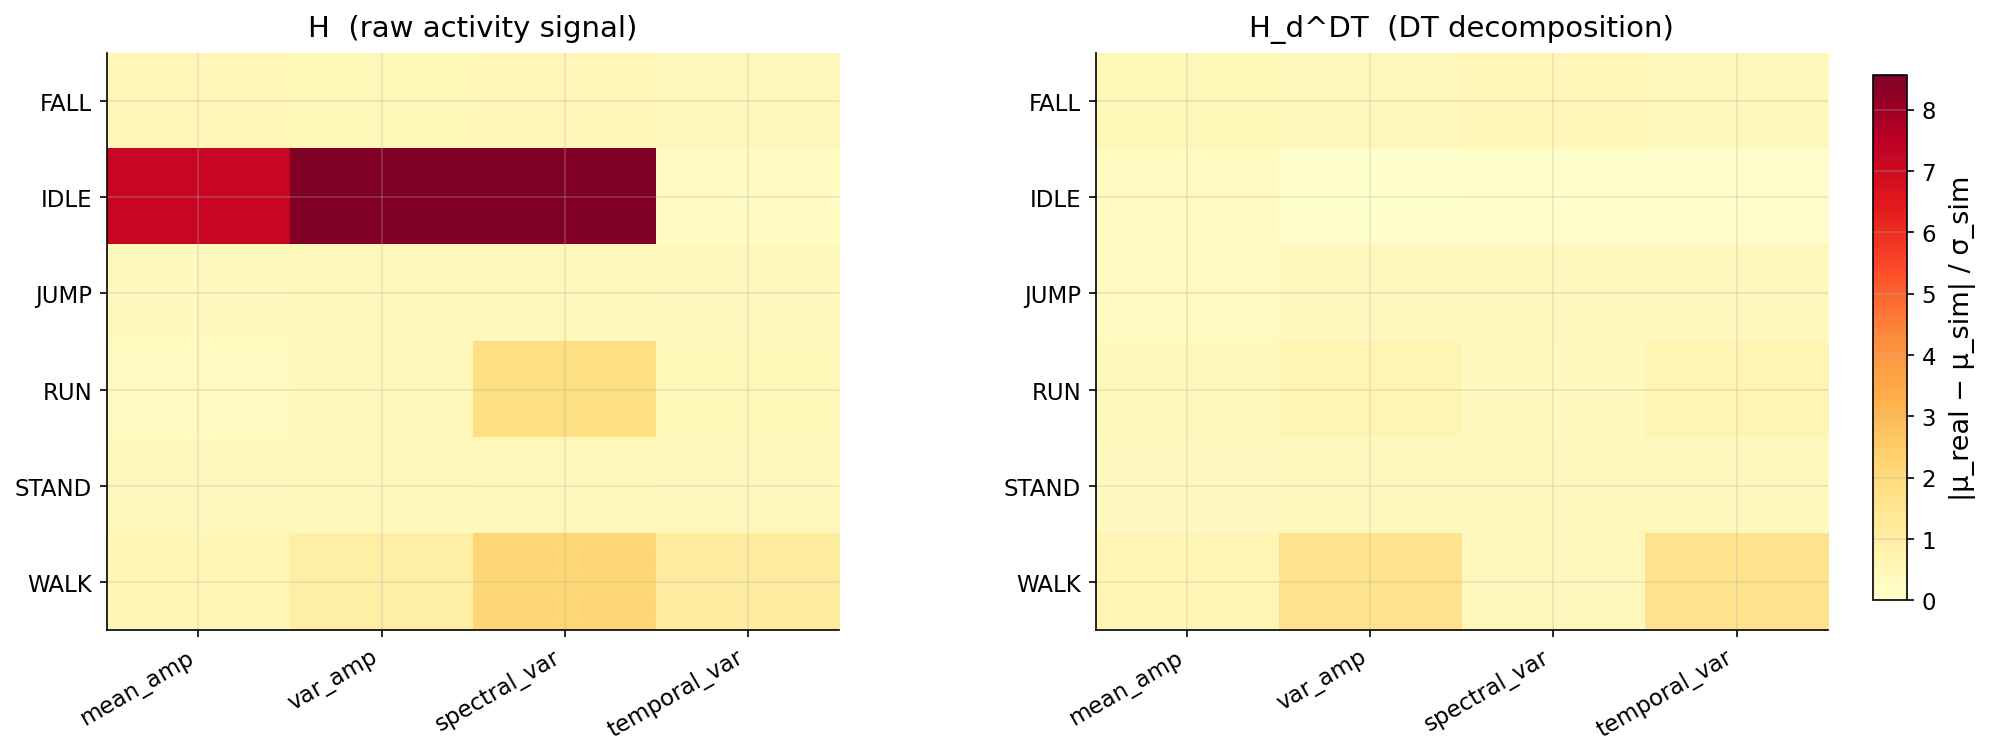

In [25]:
F_H_sim   = amp_features(H_sim)
F_H_real  = amp_features(H_real)
F_Hd_sim  = amp_features(H_d_dt_sim)    # DT decomposition
F_Hd_real = amp_features(H_d_dt_real)   # DT decomposition (calibrated real)

def domain_gap(F_sim, y_s, F_real, y_r):
    """Per-class per-feature normalised distance: |mu_real - mu_sim| / sigma_sim."""
    gap = np.full((NC, F_sim.shape[1]), np.nan)
    for ci, cls in enumerate(CLASSES):
        ms = y_s == cls
        mr = y_r == cls
        if not ms.any() or not mr.any():
            continue
        mu_s = F_sim[ms].mean(axis=0)
        sd_s = F_sim[ms].std(axis=0) + 1e-9
        mu_r = F_real[mr].mean(axis=0)
        gap[ci] = np.abs(mu_r - mu_s) / sd_s
    return gap

gap_H  = domain_gap(F_H_sim,  y_sim, F_H_real,  y_real)
gap_Hd = domain_gap(F_Hd_sim, y_sim, F_Hd_real, y_real)

print('\nCDA (cross-domain dynamic alignment, H_d^DT):')
for cls in CLASSES:
    ms = y_sim  == cls
    mr = y_real == cls
    if not ms.any() or not mr.any():
        continue
    mu_s = F_Hd_sim[ms].mean(axis=0)
    mu_r = F_Hd_real[mr].mean(axis=0)
    cda  = np.dot(mu_s, mu_r) / (np.linalg.norm(mu_s) * np.linalg.norm(mu_r) + 1e-9)
    print(f'  {cls}: {cda:.4f}')

# ── Figure G: Domain gap H vs H_d^DT ─────────────────────────────────────────
vmax_g = np.nanpercentile(np.stack([gap_H, gap_Hd]), 98)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.0))
fig.subplots_adjust(right=0.89, wspace=0.35)

for ax, (gap, title) in zip(axes, [
    (gap_H,  'H  (raw activity signal)'),
    (gap_Hd, 'H_d^DT  (DT decomposition)'),
]):
    im = ax.imshow(gap, aspect='auto', cmap='YlOrRd', vmin=0, vmax=vmax_g)
    ax.set_xticks(range(len(FEAT_NAMES_4)))
    ax.set_xticklabels(FEAT_NAMES_4, rotation=30, ha='right')
    ax.set_yticks(range(NC))
    ax.set_yticklabels(CLASSES)
    ax.set_title(title)

cax = fig.add_axes([0.91, 0.15, 0.015, 0.70])
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('|μ_real − μ_sim| / σ_sim')

save_fig(fig, '07_domain_gap_h_vs_hd')
plt.show()
plt.close()

## 9. PCA Comparison: H vs H_d

Saved: 08_pca_h_vs_hd.png/.pdf


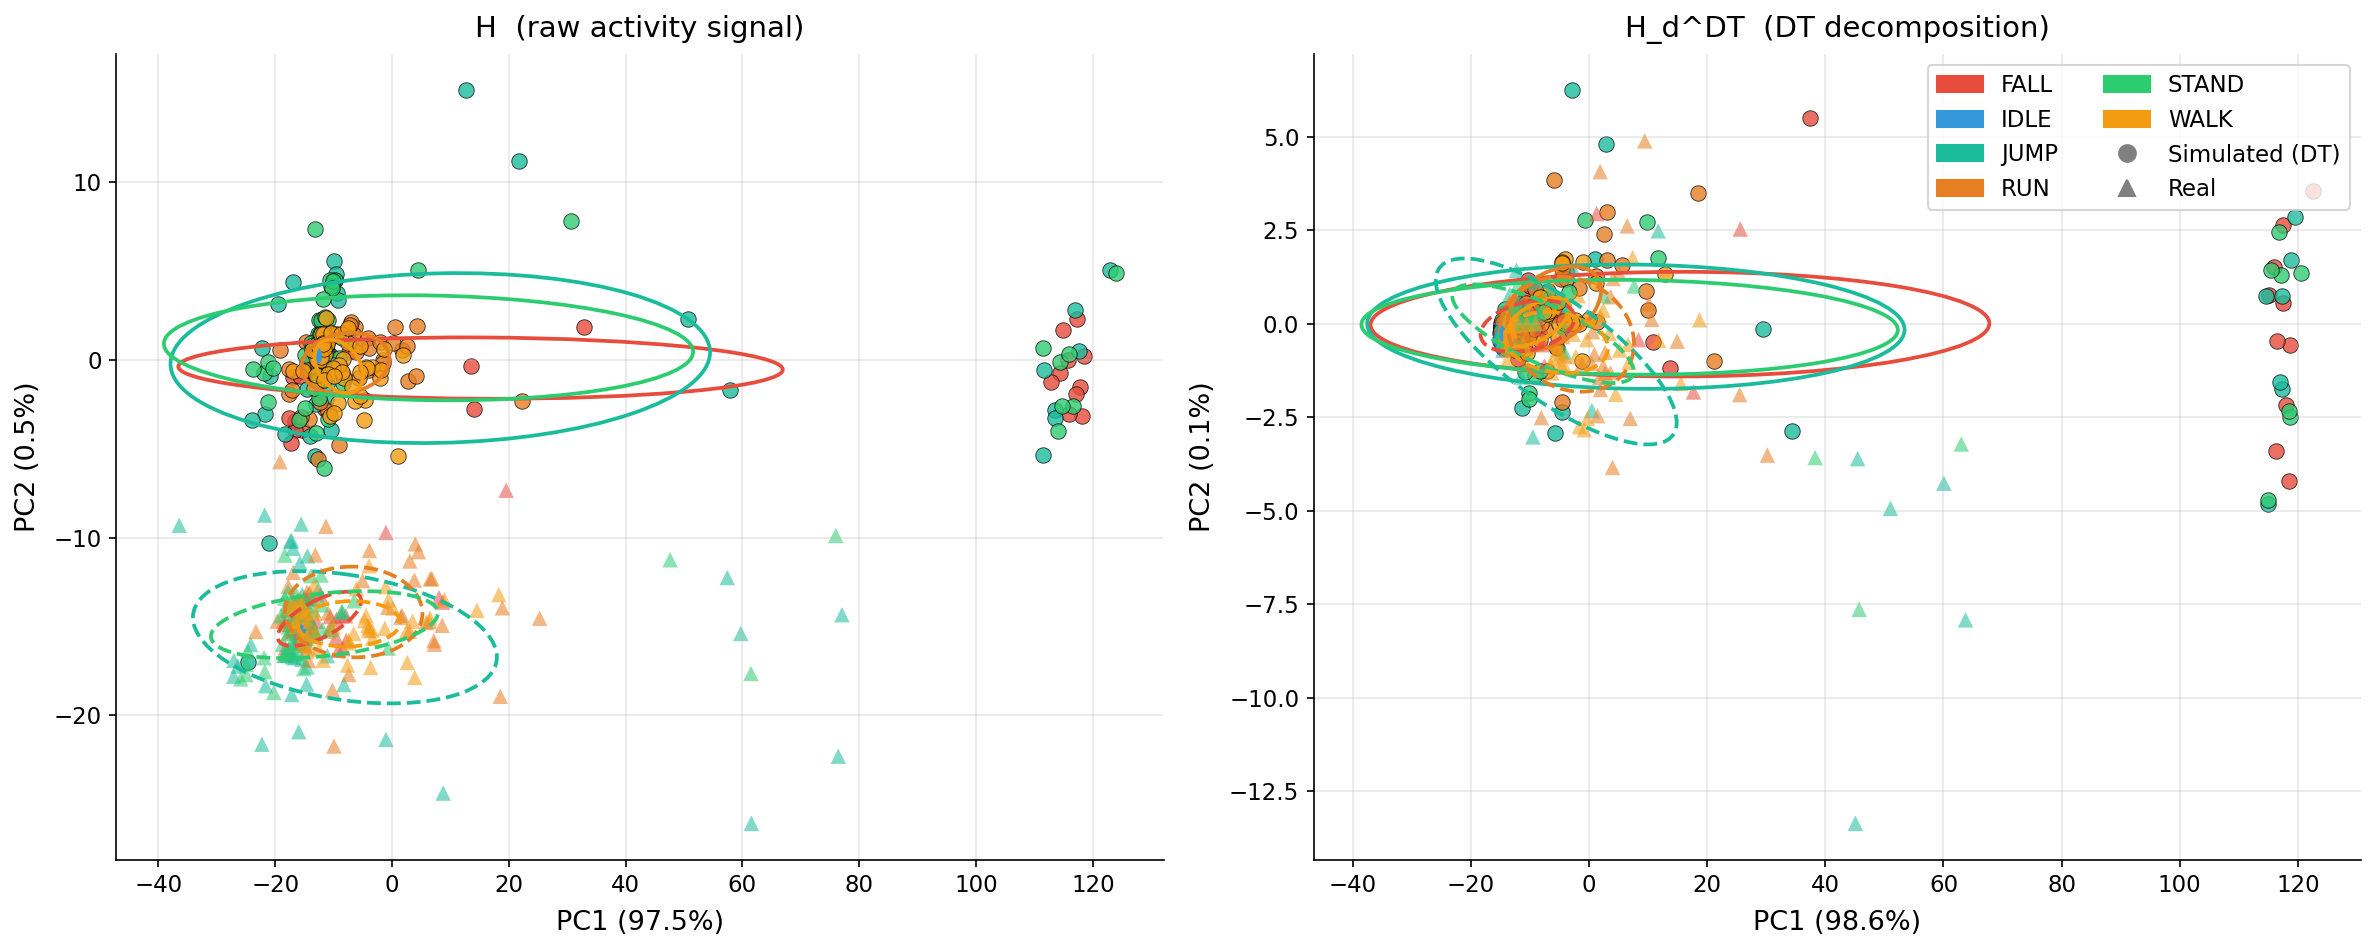

In [26]:
def confidence_ellipse(x, y, ax, n_std=1.0, **kwargs):
    if len(x) < 3:
        return
    cov = np.cov(x, y)
    eigvals, eigvecs = np.linalg.eigh(cov)
    order  = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    angle  = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))
    width  = 2 * n_std * np.sqrt(max(eigvals[0], 1e-9))
    height = 2 * n_std * np.sqrt(max(eigvals[1], 1e-9))
    ell = Ellipse(xy=(x.mean(), y.mean()), width=width, height=height,
                  angle=angle, **kwargs)
    ax.add_patch(ell)

def pca_project(H_s, H_r):
    Hs_amp = np.abs(H_s).mean(axis=1).astype(np.float32)
    Hr_amp = np.abs(H_r).mean(axis=1).astype(np.float32)
    scaler = StandardScaler()
    Fs_sc  = scaler.fit_transform(Hs_amp)
    Fr_sc  = scaler.transform(Hr_amp)
    pca    = PCA(n_components=2)
    Ps     = pca.fit_transform(Fs_sc)
    Pr     = pca.transform(Fr_sc)
    return Ps, Pr, pca.explained_variance_ratio_

Ps_H,  Pr_H,  evr_H  = pca_project(H_sim,       H_real)
Ps_Hd, Pr_Hd, evr_Hd = pca_project(H_d_dt_sim,  H_d_dt_real)   # DT decomposition

markers = {'sim': 'o', 'real': '^'}
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

for ax, (Ps, Pr, evr, title) in zip(axes, [
    (Ps_H,  Pr_H,  evr_H,  'H  (raw activity signal)'),
    (Ps_Hd, Pr_Hd, evr_Hd, 'H_d^DT  (DT decomposition)'),
]):
    for domain, P, y in [('sim', Ps, y_sim), ('real', Pr, y_real)]:
        for cls in CLASSES:
            mask = y == cls
            if not mask.any():
                continue
            ax.scatter(P[mask, 0], P[mask, 1],
                       c=CLASS_COLORS[cls], marker=markers[domain],
                       s=55, alpha=0.80 if domain == 'sim' else 0.55,
                       edgecolors='k' if domain == 'sim' else 'none',
                       linewidths=0.4)
            confidence_ellipse(P[mask, 0], P[mask, 1], ax, n_std=1.0,
                               edgecolor=CLASS_COLORS[cls], facecolor='none',
                               linewidth=1.8,
                               linestyle='-' if domain == 'sim' else '--',
                               zorder=5)
    ax.set_xlabel(f'PC1 ({evr[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({evr[1]*100:.1f}%)')
    ax.set_title(title)
    ax.autoscale_view()

class_h = [mpatches.Patch(color=CLASS_COLORS[c], label=c) for c in CLASSES]
dom_h   = [
    plt.Line2D([0], [0], marker='o', color='gray', linestyle='',
               label='Simulated (DT)', markersize=8),
    plt.Line2D([0], [0], marker='^', color='gray', linestyle='',
               label='Real',           markersize=8),
]
axes[1].legend(handles=class_h + dom_h, ncol=2, loc='upper right')

plt.tight_layout()
save_fig(fig, '08_pca_h_vs_hd')
plt.show()
plt.close()

## Summary of metrics and figures

| Figure | File | Metric(s) | Key insight |
|--------|------|-----------|-------------|
| 01 | `01_cir_profile_per_class` | — | Low-level CIR structure: dominant paths vs diffuse scattering |
| 02 | `02_bayesian_decomp_demo` | — | Visual decomposition H = H_s^DT + H_d^DT for IDLE/WALK/FALL |
| 03 | `03_static_energy_ratio` | **SER, DEF** | IDLE/STAND dominated by static energy → intrinsically hard to classify |
| 04 | `04_delay_profile_entropy` | **DPE** | FALL/JUMP concentrate delay energy (impulsive); IDLE/WALK spread across bins |
| 05 | `05_ema_alpha_sweep` | **EREC** | Identifies optimal α* and shows sim vs real background dynamics |
| 06 | `06_dynamic_discriminability_ddi` | **DDI** | Pairs where DT removal improves FDR (DDI > 1) |
| 07 | `07_domain_gap_h_vs_hd` | **CDA** | Whether removing static reduces sim→real domain gap |
| 08 | `08_pca_h_vs_hd` | — | PCA cluster quality: H vs H_d^DT — tighter clusters = more transferable features |

All figures saved as PNG (300 dpi) and PDF in `figs/dataset_v2/bayesian_plots/`.

## 10. Calibration Gap: H_s^DT(SIM) vs H_s^DT(REAL)

Confronto punto per punto dei prior statici stimati sul dataset simulato e reale.

- **Pannello 1**: spettrogramma di `|H_s^DT|` SIM — ampiezza media canale IDLE simulato (t × SC)
- **Pannello 2**: spettrogramma di `|H_s^DT|` REAL — ampiezza media canale IDLE reale
- **Pannello 3**: differenza punto per punto `||H_s^SIM| − |H_s^REAL||` — calibration gap frequenza per frequenza

Saved: 09_Hs_calibration_gap.png/.pdf


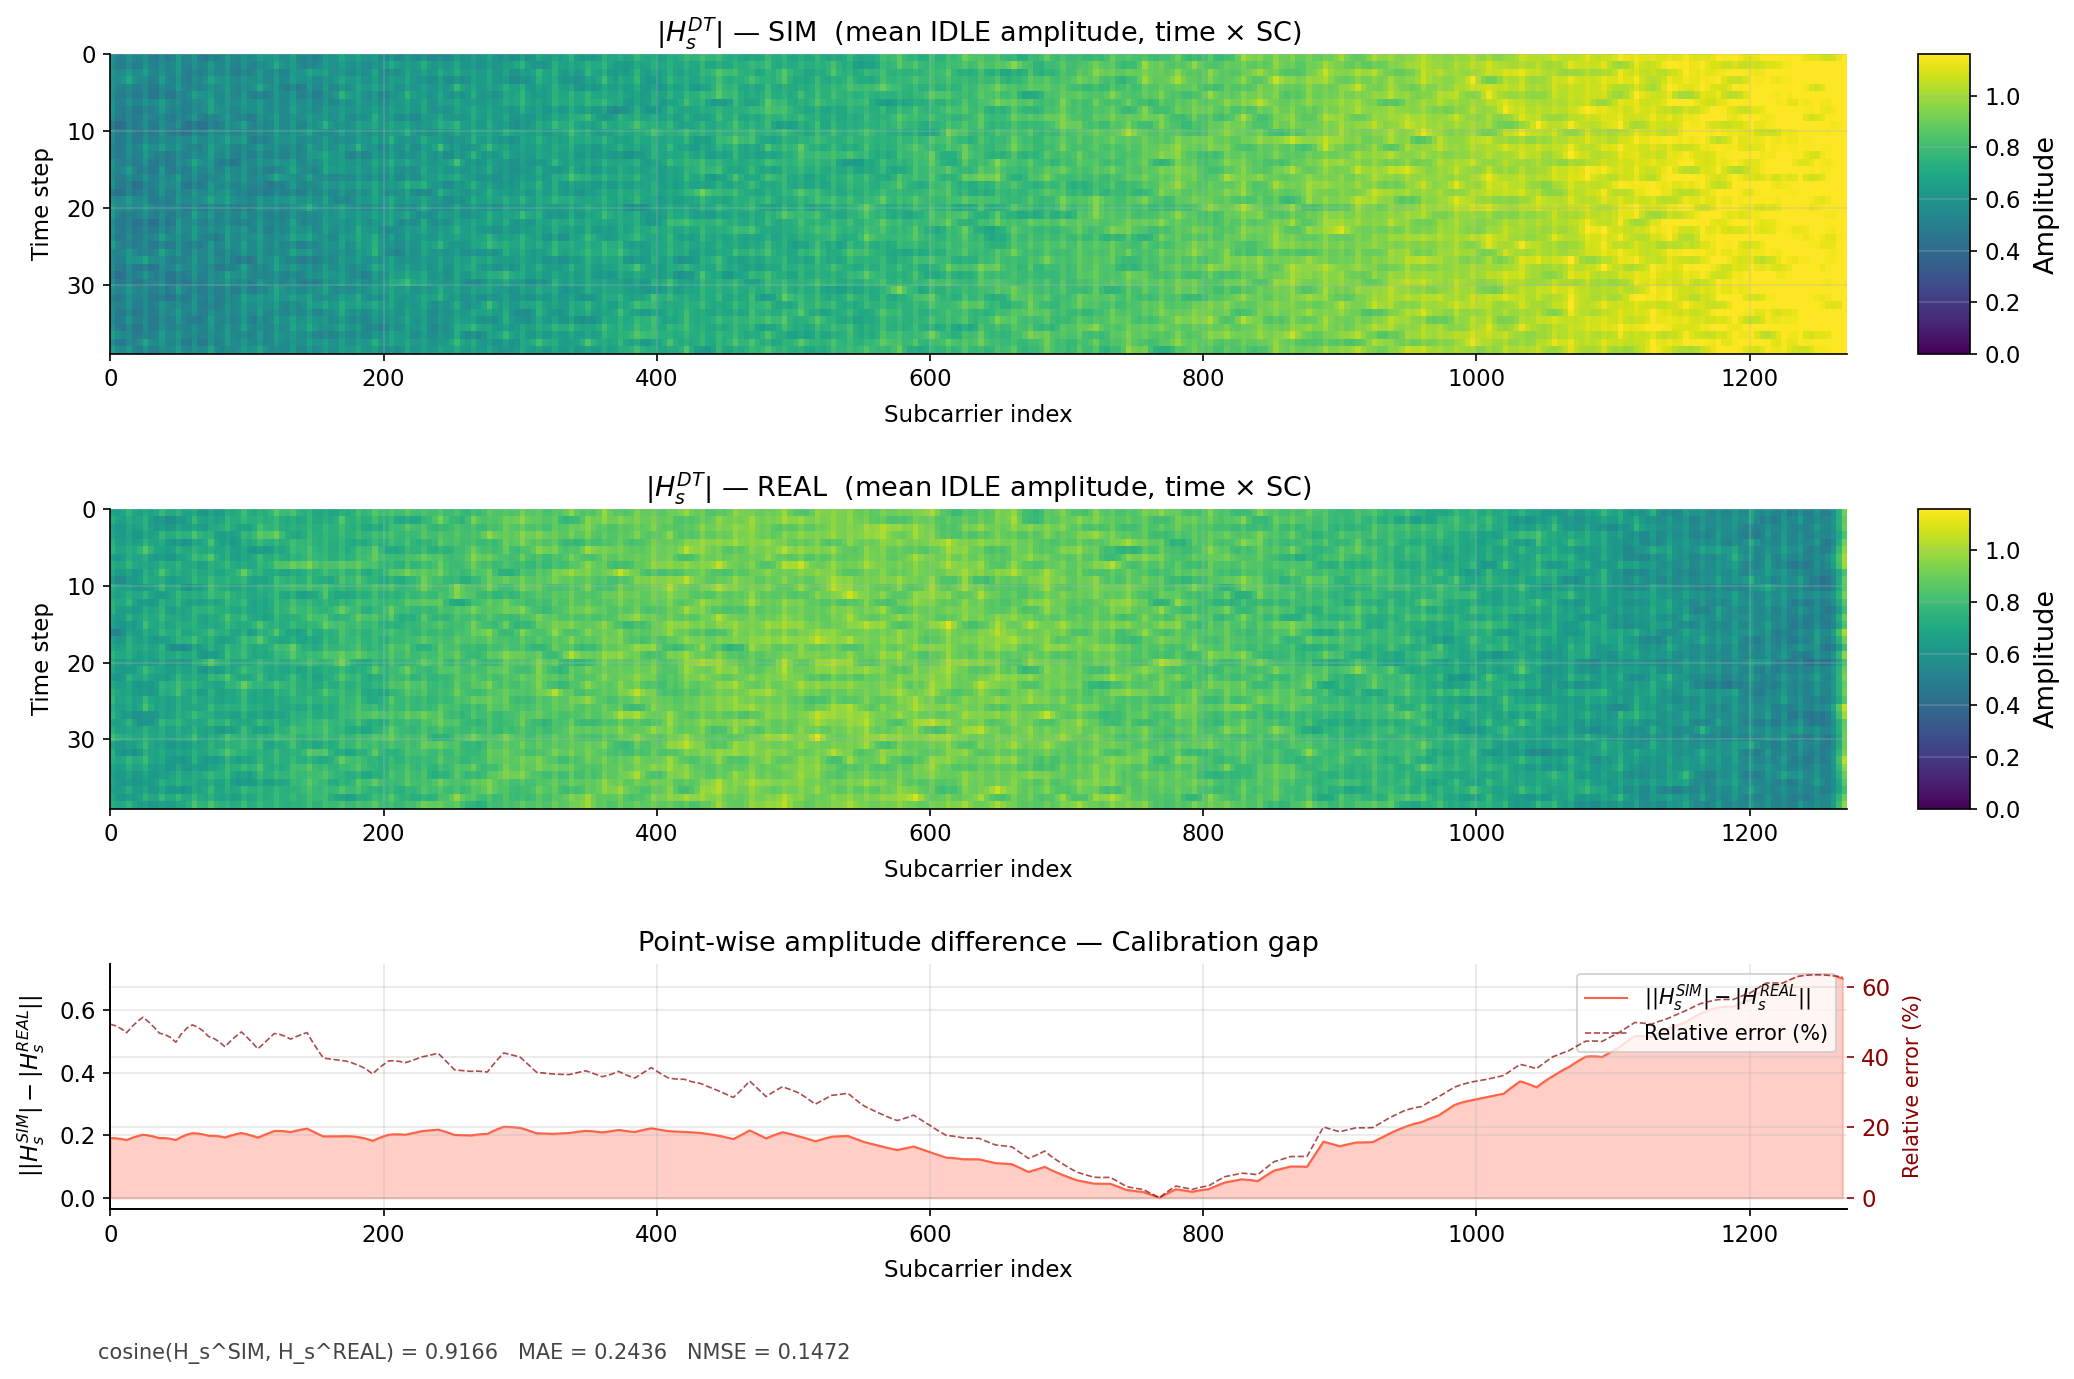


Calibration gap metrics:
  Cosine similarity : 0.9166
  MAE |Hs|          : 0.2436
  NMSE              : 0.1472
  Relative err mean : 32.3%  (median 35.0%)


In [27]:
N_SC = H_s_dt_sim.shape[0]   # 1272 subcarriers
SC_STRIDE_CG = 4   # subcarrier stride per display (1272 → 318 SC)

# Media temporale su tutti i campioni IDLE: (T=40, N_SC) per ogni dominio
# Ogni riga = un time-step; ogni colonna = una subcarrier → vero spettrogramma 2D del canale IDLE
idle_spec_sim  = np.abs(H_sim[mask_idle_sim]).mean(axis=0)    # (T, N_SC)
idle_spec_real = np.abs(H_real[mask_idle_real]).mean(axis=0)  # (T, N_SC)

# Subsample SC per visualizzazione
SC_ax   = np.arange(0, N_SC, SC_STRIDE_CG)
N_SC_d  = len(SC_ax)
disp_s  = idle_spec_sim[:,  ::SC_STRIDE_CG]   # (T, N_SC_d)
disp_r  = idle_spec_real[:, ::SC_STRIDE_CG]

# Amplitude profiles H_s^DT (media anche sul tempo)
amp_sim  = np.abs(H_s_dt_sim[::SC_STRIDE_CG])
amp_real = np.abs(H_s_dt_real[::SC_STRIDE_CG])
diff_amp = np.abs(amp_sim - amp_real)

vmax_cg = np.percentile(np.concatenate([disp_s.ravel(), disp_r.ravel()]), 98)

# Metriche di allineamento
nmse_hs = float(np.mean((amp_sim - amp_real) ** 2) / (np.mean(amp_sim ** 2) + 1e-12))
mae_hs  = float(diff_amp.mean())
rel_err = diff_amp / (amp_sim + 1e-9) * 100   # errore relativo %

fig = plt.figure(figsize=(16, 10))
gs  = fig.add_gridspec(3, 2, height_ratios=[2.2, 2.2, 1.8],
                        width_ratios=[1, 0.03], hspace=0.55, wspace=0.08)

ax0  = fig.add_subplot(gs[0, 0])
cax0 = fig.add_subplot(gs[0, 1])
ax1  = fig.add_subplot(gs[1, 0])
cax1 = fig.add_subplot(gs[1, 1])
ax2  = fig.add_subplot(gs[2, 0])
fig.add_subplot(gs[2, 1]).set_visible(False)

# ── Pannello 1: H_s^DT SIM ───────────────────────────────────────────────────
im0 = ax0.imshow(disp_s, aspect='auto', origin='upper',
                 cmap='viridis', vmin=0, vmax=vmax_cg,
                 extent=[0, N_SC - 1, disp_s.shape[0] - 1, 0])
ax0.set_title(r'$|H_s^{DT}|$ — SIM  (mean IDLE amplitude, time × SC)',
              fontsize=13, pad=6)
ax0.set_xlabel('Subcarrier index', fontsize=11)
ax0.set_ylabel('Time step', fontsize=11)
fig.colorbar(im0, cax=cax0, label='Amplitude')

# ── Pannello 2: H_s^DT REAL ──────────────────────────────────────────────────
im1 = ax1.imshow(disp_r, aspect='auto', origin='upper',
                 cmap='viridis', vmin=0, vmax=vmax_cg,
                 extent=[0, N_SC - 1, disp_r.shape[0] - 1, 0])
ax1.set_title(r'$|H_s^{DT}|$ — REAL  (mean IDLE amplitude, time × SC)',
              fontsize=13, pad=6)
ax1.set_xlabel('Subcarrier index', fontsize=11)
ax1.set_ylabel('Time step', fontsize=11)
fig.colorbar(im1, cax=cax1, label='Amplitude')

# ── Pannello 3: differenza punto per punto ───────────────────────────────────
ax2.fill_between(SC_ax, 0, diff_amp, color='tomato', alpha=0.30)
ax2.plot(SC_ax, diff_amp, color='tomato', lw=1.0,
         label=r'$||H_s^{SIM}| - |H_s^{REAL}||$')

ax2r = ax2.twinx()
ax2r.plot(SC_ax, rel_err, color='#8B0000', lw=0.8, linestyle='--', alpha=0.7,
          label='Relative error (%)')
ax2r.set_ylabel('Relative error (%)', color='#8B0000', fontsize=10)
ax2r.tick_params(axis='y', colors='#8B0000')

ax2.set_xlabel('Subcarrier index', fontsize=11)
ax2.set_ylabel(r'$||H_s^{SIM}| - |H_s^{REAL}||$', fontsize=11)
ax2.set_title(r'Point-wise amplitude difference — Calibration gap',
              fontsize=13, pad=6)
ax2.set_xlim(0, N_SC - 1)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2r.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

fig.text(0.12, 0.01,
         f'cosine(H_s^SIM, H_s^REAL) = {cos_sim:.4f}   '
         f'MAE = {mae_hs:.4f}   NMSE = {nmse_hs:.4f}',
         fontsize=10, color='#444444')

save_fig(fig, '09_Hs_calibration_gap')
plt.show()
plt.close()

print(f'\nCalibration gap metrics:')
print(f'  Cosine similarity : {cos_sim:.4f}')
print(f'  MAE |Hs|          : {mae_hs:.4f}')
print(f'  NMSE              : {nmse_hs:.4f}')
print(f'  Relative err mean : {rel_err.mean():.1f}%  (median {np.median(rel_err):.1f}%)')

## 11. Phase Dilution: Why Static Subtraction Is Necessary for Phase-Based Doppler Features

Motivates the Remark in `main_v3.tex` (`rem:phase-dilution`): does temporal differencing of the
**raw** channel `H(t) = H_s + H_d(t)` cancel `H_s` automatically, making an explicit static-subtraction
step unnecessary?

- For the **complex-valued difference** `H(t)-H(t-1) = H_d(t)-H_d(t-1)`, yes — `H_s` cancels exactly.
- For **phase-based** features (`angle(H)`, used by most of the 20 Doppler channels in
  `csi_har_benchmark_pt.py::augment_features`), no — `angle` is a nonlinear function, and when
  `‖H_s‖ ≫ ‖H_d‖`, `angle(H_s+H_d(t)) ≈ angle(H_s) + Im[H_d(t)·e^{-jθ_s}] / ‖H_s‖`: the motion signal is
  diluted by the ratio `‖H_d‖/‖H_s‖`.

This section quantifies the dilution directly on `dataset_v3` (36-position grid, matching the
results reported in the paper), by comparing paired trajectories from `H_activity` (isolated
`H_d`, i.e. `H_s` already removed at simulation time) and `H_combined` (raw `H_s+H_d`, same
trajectory index) — see `--subtract-mode combined` in `csi_har_benchmark_pt.py` and
`project_benchmark_stato.md` for the full experimental context.

> **Dataset**: raw CSVs from `dataset_v3/` (not the cached `.npz`, which only stores one
> representation at a time) — read directly via `csi_har_benchmark_pt._raw_csv_to_array` to
> guarantee correct pairing between isolated and raw versions of the same trajectory.

In [ ]:
import glob
import sys
sys.path.insert(0, '.')
from csi_har_benchmark_pt import _raw_csv_to_array

PD_BASE_DIR   = 'dataset_v3'
PD_CLASSES    = ['FALL', 'JUMP', 'RUN', 'STAND', 'WALK']   # IDLE = noise-floor reference
PD_CLASS_DIRS = {
    'FALL':  'fall_furnished',
    'JUMP':  'jump_furnished',
    'RUN':   'run_furnished',
    'STAND': 'stand_furnished',
    'WALK':  'walk_furnished',
}
PD_IDLE_DIR = 'furnished_idle'
PD_N_RX     = 6     # sampled RX positions (out of 36)
PD_N_TRAJ   = 10    # trajectories per RX position
OUT_DIR_V3  = 'figs/dataset_v3/bayesian_plots'
os.makedirs(OUT_DIR_V3, exist_ok=True)


def pd_complex(H):
    return H[..., 0].astype(np.float64) + 1j * H[..., 1].astype(np.float64)

def pd_phase_diff_energy(H):
    """Mean |diff(unwrap(angle(H)))| over time and subcarrier — per-sample scalar."""
    pha = np.unwrap(H[..., 3].astype(np.float64), axis=0)
    return np.abs(np.diff(pha, axis=0)).mean()

def pd_mag_diff_energy(H_cx):
    """Mean |diff(H_cx)| — complex-channel difference, per-sample scalar."""
    return np.abs(np.diff(H_cx, axis=0)).mean()

def pd_sample_rx_ids(class_dir, n_rx, seed=0):
    rx_dirs = sorted(int(d.split('rx')[-1]) for d in glob.glob(f'{PD_BASE_DIR}/{class_dir}/rx*'))
    rng = np.random.default_rng(seed)
    return sorted(rng.choice(rx_dirs, size=min(n_rx, len(rx_dirs)), replace=False))

def pd_collect_idle_baseline(rx_ids, n_traj):
    phase_vals, mag_vals = [], []
    for rx in rx_ids:
        files = sorted(glob.glob(f'{PD_BASE_DIR}/{PD_IDLE_DIR}/rx{rx}/H_activity_v*.csv'))[:n_traj]
        for f in files:
            H = _raw_csv_to_array(f)
            phase_vals.append(pd_phase_diff_energy(H))
            mag_vals.append(pd_mag_diff_energy(pd_complex(H)))
    return np.array(phase_vals), np.array(mag_vals)

def pd_collect_class_samples(cls, rx_ids, n_traj):
    """Paired isolated H_d (H_activity) vs raw H_s+H_d (H_combined), same trajectory index."""
    class_dir = PD_CLASS_DIRS[cls]
    phase_iso, phase_raw, mag_iso, mag_raw = [], [], [], []
    for rx in rx_ids:
        act_files = sorted(glob.glob(f'{PD_BASE_DIR}/{class_dir}/rx{rx}/H_activity_v*.csv'))[:n_traj]
        for act_path in act_files:
            comb_path = act_path.replace('H_activity_v', 'H_combined_v')
            if not os.path.exists(comb_path):
                continue
            H_act, H_comb = _raw_csv_to_array(act_path), _raw_csv_to_array(comb_path)
            phase_iso.append(pd_phase_diff_energy(H_act))
            phase_raw.append(pd_phase_diff_energy(H_comb))
            mag_iso.append(pd_mag_diff_energy(pd_complex(H_act)))
            mag_raw.append(pd_mag_diff_energy(pd_complex(H_comb)))
    return (np.array(phase_iso), np.array(phase_raw), np.array(mag_iso), np.array(mag_raw))


print('Sampling RX positions and IDLE trajectories for the noise floor...')
pd_rx_ids = pd_sample_rx_ids(PD_IDLE_DIR, PD_N_RX)
print(f'  RX sampled: {pd_rx_ids}')
idle_phase, idle_mag = pd_collect_idle_baseline(pd_rx_ids, PD_N_TRAJ)
idle_phase_ref, idle_mag_ref = idle_phase.mean(), idle_mag.mean()
print(f'  IDLE phase-diff : mean={idle_phase_ref:.5f}  (N={len(idle_phase)})')
print(f'  IDLE mag-diff   : mean={idle_mag_ref:.5f}  (N={len(idle_mag)})')

pd_results = {}
print('\nComputing per-class SNR (isolated H_d vs raw H_s+H_d)...')
for cls in PD_CLASSES:
    p_iso, p_raw, m_iso, m_raw = pd_collect_class_samples(cls, pd_rx_ids, PD_N_TRAJ)
    pd_results[cls] = dict(
        snr_phase_iso=p_iso / idle_phase_ref, snr_phase_raw=p_raw / idle_phase_ref,
        snr_mag_iso=m_iso / idle_mag_ref,     snr_mag_raw=m_raw / idle_mag_ref,
        n=len(p_iso),
    )
    r = pd_results[cls]
    print(f'  {cls:6s} (N={r["n"]:3d})  '
          f'SNR-phase: isolated={r["snr_phase_iso"].mean():6.2f}x  raw={r["snr_phase_raw"].mean():5.2f}x   |   '
          f'SNR-mag: isolated={r["snr_mag_iso"].mean():5.2f}x  raw={r["snr_mag_raw"].mean():5.2f}x')


In [ ]:
# ── Figure 10: Phase-dilution SNR — isolated H_d vs raw H_s+H_d ──────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
x = np.arange(len(PD_CLASSES))
width = 0.35

for ax, key_iso, key_raw, title, ylabel in [
    (axes[0], 'snr_phase_iso', 'snr_phase_raw',
     r'Phase-difference SNR ($\angle H$)', r'SNR vs IDLE noise floor ($\times$)'),
    (axes[1], 'snr_mag_iso', 'snr_mag_raw',
     r'Complex-difference SNR ($|\Delta H|$)', ''),
]:
    means_iso = [pd_results[c][key_iso].mean() for c in PD_CLASSES]
    stds_iso  = [pd_results[c][key_iso].std()  for c in PD_CLASSES]
    means_raw = [pd_results[c][key_raw].mean() for c in PD_CLASSES]
    stds_raw  = [pd_results[c][key_raw].std()  for c in PD_CLASSES]

    ax.bar(x - width/2, means_iso, width, yerr=stds_iso, capsize=3,
           label='isolated $H_d$ (H_activity)', color='#2c3e50', alpha=0.85)
    ax.bar(x + width/2, means_raw, width, yerr=stds_raw, capsize=3,
           label='raw $H_s+H_d$ (H_combined)', color='#c0392b', alpha=0.85)
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='IDLE noise floor')
    ax.set_yscale('log')
    ax.set_xticks(x)
    ax.set_xticklabels(PD_CLASSES)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9, loc='upper right')

fig.suptitle('Phase-based Doppler features require static subtraction; '
              'complex-difference amplitude does not', fontsize=13)
fig.tight_layout()
fig.savefig(f'{OUT_DIR_V3}/10_phase_dilution_snr.pdf', dpi=300, bbox_inches='tight')
fig.savefig(f'{OUT_DIR_V3}/10_phase_dilution_snr.png', dpi=300, bbox_inches='tight')
print(f'Saved: 10_phase_dilution_snr.png/.pdf  →  {OUT_DIR_V3}/')
plt.show()
plt.close()